---
# 2026

----
## v5
Contexto:
> * 30390 registros para bar 5 y 20334 registros para bar 3

Solución:
> Aplciar ETL a los datos y reentrenar NN

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from shapely.geometry import Point, Polygon
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.optimize import brentq
import requests
import io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, r2_score

### Datasets

In [ ]:
url = 'https://raw.githubusercontent.com/leito92/EEM/main/data/v2.csv'
df_5 = pd.read_csv(url, sep=';')
display(df_5)

url2 = 'https://raw.githubusercontent.com/leito92/EEM/main/data/v5.csv'
df_3 = pd.read_csv(url2, sep=';')
display(df_3)

,#,presion_entrada,mfc,pcv,caudal_camara,presion_camara
0,Case 1,5,100,"99,99",1,"1,909"
1,Case 2,5,100,"99,99","0,9999","1,911"
2,Case 3,5,100,"99,99","0,9998","1,913"
3,Case 4,5,100,"99,99","0,9997","1,915"
4,Case 5,5,100,"99,99","0,9996","1,917"
...,...,...,...,...,...,...
30385,Case 99906,5,10,0,"0,0014","4,996"
30386,Case 99907,5,10,0,"0,0013","4,997"
30387,Case 99908,5,10,0,"0,0012","4,997"
30388,Case 99909,5,10,0,"0,0011","4,998"


,#,presion_entrada,mfc,pcv,caudal_camara,presion_camara
0,Case 3209,3,100,100.0,0.6792,0.4004
1,Case 3210,3,100,100.0,0.6791,0.4236
2,Case 3211,3,100,100.0,0.6790,0.4408
3,Case 3212,3,100,100.0,0.6789,0.4551
4,Case 3213,3,100,100.0,0.6788,0.4676
...,...,...,...,...,...,...
20329,Case 99908,3,10,0.0,0.0012,2.9960
20330,Case 99909,3,10,0.0,0.0011,2.9970
20331,Case 99910,3,10,0.0,0.0010,2.9970
20332,Maximum,3,100,100.0,1.0000,3.0000


In [ ]:
# Convertir columnas con comas a formato numérico con puntos
columns_to_convert = ['pcv', 'caudal_camara', 'presion_camara']
for col in columns_to_convert:
    if col in df_5.columns:
        df_5[col] = df_5[col].astype(str).str.replace(',', '.', regex=False).astype(float)

columns_to_convert = ['pcv', 'caudal_camara', 'presion_camara']
for col in columns_to_convert:
    if col in df_3.columns:
        df_3[col] = df_3[col].astype(str).str.replace(',', '.', regex=False).astype(float)

### Gráfico

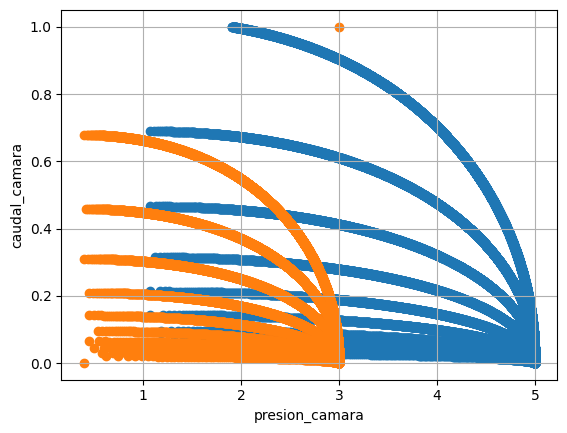

In [ ]:
plt.scatter(df_5['presion_camara'], df_5['caudal_camara'])
plt.scatter(df_3['presion_camara'], df_3['caudal_camara'])
plt.xlabel('presion_camara')
plt.ylabel('caudal_camara')
plt.grid(True)
plt.show()

### ETL

In [ ]:
df_3 = df_3.iloc[:-2]

In [ ]:
x_grid = np.sort(
    df_3["presion_camara"].unique()
)

curvas = []

for mfc, g in df_3.groupby("mfc"):

    g = g.sort_values("presion_camara")

    f = interp1d(
        g["presion_camara"],
        g["caudal_camara"],
        bounds_error=False,
        fill_value=np.nan
    )

    curvas.append(f(x_grid))

curvas = np.array(curvas)

y_sup = np.nanmax(curvas, axis=0)

In [ ]:
contorno_superior = np.column_stack(
    [x_grid, y_sup]
)

contorno_inferior = np.column_stack(
    [x_grid[::-1], np.zeros_like(x_grid)]
)

vertices = np.vstack(
    [contorno_superior, contorno_inferior]
)

polygon = Polygon(vertices)

In [ ]:
mask = []

for _, row in df_5.iterrows():

    p = Point(
        row["presion_camara"],
        row["caudal_camara"]
    )

    mask.append(
        not polygon.contains(p)
    )

df_5_filtrado = df_5[mask].copy()

In [ ]:
df_final = pd.concat(
    [df_3, df_5_filtrado],
    ignore_index=True
)
display(df_final)

,#,presion_entrada,mfc,pcv,caudal_camara,presion_camara
0,Case 3209,3,100,100.0,0.6792,0.4004
1,Case 3210,3,100,100.0,0.6791,0.4236
2,Case 3211,3,100,100.0,0.6790,0.4408
3,Case 3212,3,100,100.0,0.6789,0.4551
4,Case 3213,3,100,100.0,0.6788,0.4676
...,...,...,...,...,...,...
49558,Case 99906,5,10,0.0,0.0014,4.9960
49559,Case 99907,5,10,0.0,0.0013,4.9970
49560,Case 99908,5,10,0.0,0.0012,4.9970
49561,Case 99909,5,10,0.0,0.0011,4.9980


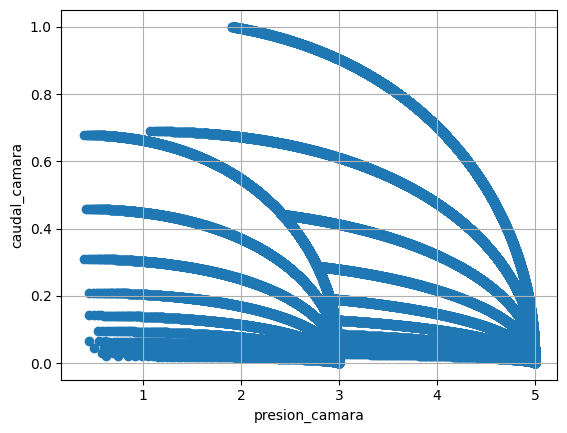

In [ ]:
plt.scatter(df_final["presion_camara"], df_final["caudal_camara"])
plt.xlabel('presion_camara')
plt.ylabel('caudal_camara')
plt.grid(True)
plt.show()

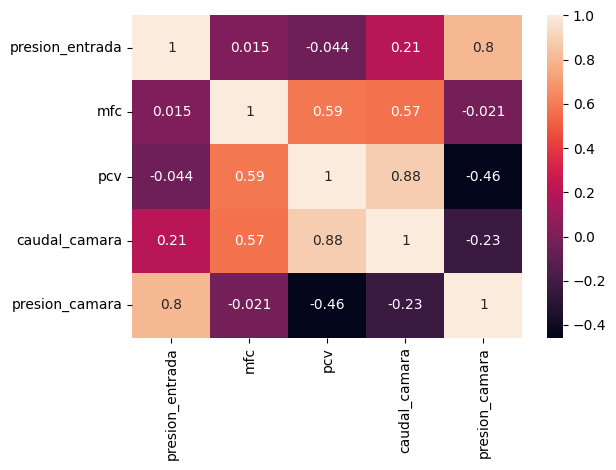

In [ ]:
matriz_corr = df_final.drop(columns=['#']).corr()
sns.heatmap(
    matriz_corr,
    annot=True
)
plt.tight_layout()
plt.show()

### Modelo NN

In [ ]:
def prepare_data(df):
  X = df[["presion_camara", "mfc", "presion_entrada"]]
  y = df[["caudal_camara","pcv"]]

  X_rest, X_blind, y_rest, y_blind = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
  )

  X_train, X_test, y_train, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.20,
    random_state=42
  )

  total = len(X)
  print(f"PARTICIONES DE DATOS:")
  print(f"Total: {total} pts (100%)")
  print(f"Train: {len(X_train)} pts ({len(X_train)/total*100:.1f}%)")
  print(f"Test: {len(X_test)} pts ({len(X_test)/total*100:.1f}%)")
  print(f"Blind: {len(X_blind)} pts ({len(X_blind)/total*100:.1f}%)")

  return X_train, X_test, X_blind, y_train, y_test, y_blind

In [ ]:
X_train, X_test, X_blind, y_train, y_test, y_blind = prepare_data(df_final)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

PARTICIONES DE DATOS:
Total: 49563 pts (100%)
Train: 35684 pts (72.0%)
Test: 8922 pts (18.0%)
Blind: 4957 pts (10.0%)


In [ ]:
class MLP(nn.Module): # Multilayer Perceptron
    def __init__(self):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
tensor_X_train = torch.FloatTensor(X_train_scaled)
tensor_y_train = torch.FloatTensor(y_train_scaled)
dataset_train = TensorDataset(tensor_X_train, tensor_y_train)
loader_train = DataLoader(dataset_train, batch_size=256, shuffle=True)

In [ ]:
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

tensor_X_test = torch.FloatTensor(X_test_scaled)
tensor_y_test = torch.FloatTensor(y_test_scaled)

dataset_test = TensorDataset(tensor_X_test, tensor_y_test)
loader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

In [ ]:
modelo = MLP()
criterio = nn.MSELoss()
optimizador = optim.AdamW(modelo.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador,
    mode='min', # minimizar loss
    patience=10,
    factor=0.5 # reducir lr a la mitad
)

epochs = 300
historial_train = []
historial_val = []

for epoch in range(epochs):
    modelo.train()
    loss_total = 0
    for batch_X, batch_y in loader_train:
        optimizador.zero_grad()
        preds = modelo(batch_X)
        loss = criterio(preds, batch_y)
        loss.backward()
        optimizador.step()
        loss_total += loss.item()
    loss_train = loss_total / len(loader_train)
    historial_train.append(loss_train)

    modelo.eval()
    loss_val_total = 0
    with torch.no_grad():
        for batch_X, batch_y in loader_test:
            preds_val = modelo(batch_X)
            loss_val_total += criterio(preds_val, batch_y).item()
    loss_val = loss_val_total / len(loader_test)
    historial_val.append(loss_val)

    scheduler.step(loss_train)

    if epoch % 10 == 0:
        lr_actual = optimizador.param_groups[0]['lr']
        print(f"Época [{epoch}/{epochs}] -> Loss_Train: {loss_train:.6f} | Loss_Val: {loss_val:.6f} | LR: {lr_actual:.6f}")

Época [0/300] -> Loss_Train: 0.033686 | Loss_Val: 0.012724 | LR: 0.001000
Época [10/300] -> Loss_Train: 0.001482 | Loss_Val: 0.001323 | LR: 0.001000
Época [20/300] -> Loss_Train: 0.000753 | Loss_Val: 0.000743 | LR: 0.001000
Época [30/300] -> Loss_Train: 0.000664 | Loss_Val: 0.000837 | LR: 0.001000
Época [40/300] -> Loss_Train: 0.000852 | Loss_Val: 0.000448 | LR: 0.001000
Época [50/300] -> Loss_Train: 0.000444 | Loss_Val: 0.000322 | LR: 0.001000
Época [60/300] -> Loss_Train: 0.000353 | Loss_Val: 0.000473 | LR: 0.001000
Época [70/300] -> Loss_Train: 0.000513 | Loss_Val: 0.000257 | LR: 0.001000
Época [80/300] -> Loss_Train: 0.000248 | Loss_Val: 0.000214 | LR: 0.000500
Época [90/300] -> Loss_Train: 0.000234 | Loss_Val: 0.000204 | LR: 0.000500
Época [100/300] -> Loss_Train: 0.000237 | Loss_Val: 0.000219 | LR: 0.000250
Época [110/300] -> Loss_Train: 0.000193 | Loss_Val: 0.000175 | LR: 0.000250
Época [120/300] -> Loss_Train: 0.000189 | Loss_Val: 0.000312 | LR: 0.000250
Época [130/300] -> Loss

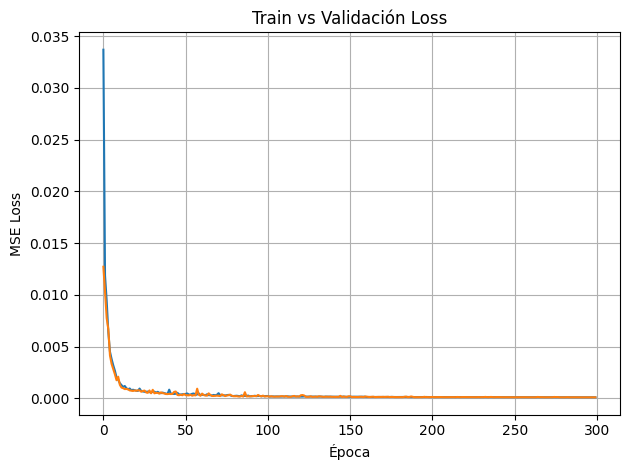

In [ ]:
plt.figure()
plt.plot(historial_train, label='Loss Train')
plt.plot(historial_val, label='Loss Val')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('Train vs Validación Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

### Test

In [ ]:
def metrics(modelo, scaler_X, scaler_y, X_eval, y_eval, nombre_set):
    modelo.eval()

    # Escalar entradas y predecir
    X_eval_scaled = scaler_X.transform(X_eval)
    with torch.no_grad():
        tensor_X = torch.FloatTensor(X_eval_scaled)
        y_pred_scaled = modelo(tensor_X).numpy()

    # Desescalar predicciones a unidades físicas reales
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    # Separar variables para evaluación individual
    caudal_real, caudal_pred = y_eval.iloc[:, 0], y_pred[:, 0]
    pcv_real, pcv_pred = y_eval.iloc[:, 1], y_pred[:, 1]

    # Métricas Caudal
    mse_q = mean_squared_error(caudal_real, caudal_pred)
    rmse_q = np.sqrt(mse_q)
    r2_q = r2_score(caudal_real, caudal_pred)

    # Métricas PCV
    mse_v = mean_squared_error(pcv_real, pcv_pred)
    rmse_v = np.sqrt(mse_v)
    r2_v = r2_score(pcv_real, pcv_pred)

    # Resultados
    print(f"\nSet: {nombre_set}")
    print(f"Variable: CAUDAL EN CÁMARA")
    print(f"- MSE: {mse_q:.6f}")
    print(f"- RMSE: {rmse_q:.6f}")
    print(f"- R²: {r2_q:.4f}")
    print(f"Variable: PCV")
    print(f"- MSE: {mse_v:.6f}")
    print(f"- RMSE: {rmse_v:.6f}")
    print(f"- R²: {r2_v:.4f}")

    resultado = pd.DataFrame({
      'caudal_camara_real': caudal_real.values,
      'caudal_camara_pred': caudal_pred.round(4),
      'pcv_real':           pcv_real.values,
      'pcv_pred':           pcv_pred.round(4)
    })
    display(resultado)

    fig, ax = plt.subplots(1,2, figsize=(12, 5))
    ax[0].scatter(df_final["presion_camara"], df_final["caudal_camara"], alpha=0.3, s=10)
    ax[0].scatter(
        X_eval['presion_camara'], y_pred[:, 0],
        marker="X", color="red", s=10
    )
    ax[0].set_xlabel('presion_camara')
    ax[0].set_ylabel('caudal_camara')
    ax[0].grid(True)

    ax[1].scatter(df_final["caudal_camara"], df_final["pcv"], alpha=0.3, s=10)
    ax[1].scatter(
        y_eval['caudal_camara'], y_pred[:, 1],
        marker="X", color="red", s=10
    )
    ax[1].set_xlabel('caudal_camara')
    ax[1].set_ylabel('pcv')
    ax[1].grid(True)

    plt.show()


Set: TEST
Variable: CAUDAL EN CÁMARA
- MSE: 0.000013
- RMSE: 0.003556
- R²: 0.9998
Variable: PCV
- MSE: 2.114807
- RMSE: 1.454238
- R²: 0.9974


,caudal_camara_real,caudal_camara_pred,pcv_real,pcv_pred
0,0.3839,0.3830,57.16,56.744499
1,0.3059,0.3038,54.38,53.783501
2,0.0802,0.0736,26.64,21.913401
3,0.7299,0.7285,77.62,77.765999
4,0.2854,0.2841,49.07,49.771500
...,...,...,...,...
8917,0.8296,0.8280,83.45,83.261200
8918,0.1239,0.1240,27.16,27.511200
8919,0.2618,0.2622,47.47,47.102200
8920,0.2300,0.2310,45.13,46.030800


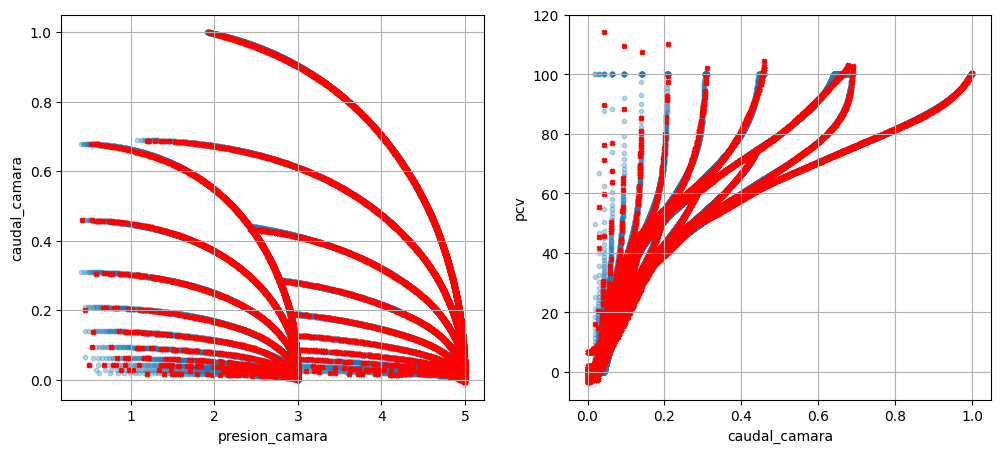


Set: BLIND
Variable: CAUDAL EN CÁMARA
- MSE: 0.000013
- RMSE: 0.003658
- R²: 0.9998
Variable: PCV
- MSE: 2.380386
- RMSE: 1.542850
- R²: 0.9971


,caudal_camara_real,caudal_camara_pred,pcv_real,pcv_pred
0,0.6654,0.6643,87.64,87.279099
1,0.1114,0.1029,24.31,20.671301
2,0.1757,0.1823,47.41,49.685600
3,0.1551,0.1505,33.09,32.184700
4,0.4437,0.4412,63.65,63.158298
...,...,...,...,...
4952,0.1272,0.1274,27.84,28.243601
4953,0.0216,0.0295,0.00,7.692700
4954,0.3278,0.3255,52.86,52.538502
4955,0.0475,0.0441,2.51,5.808500


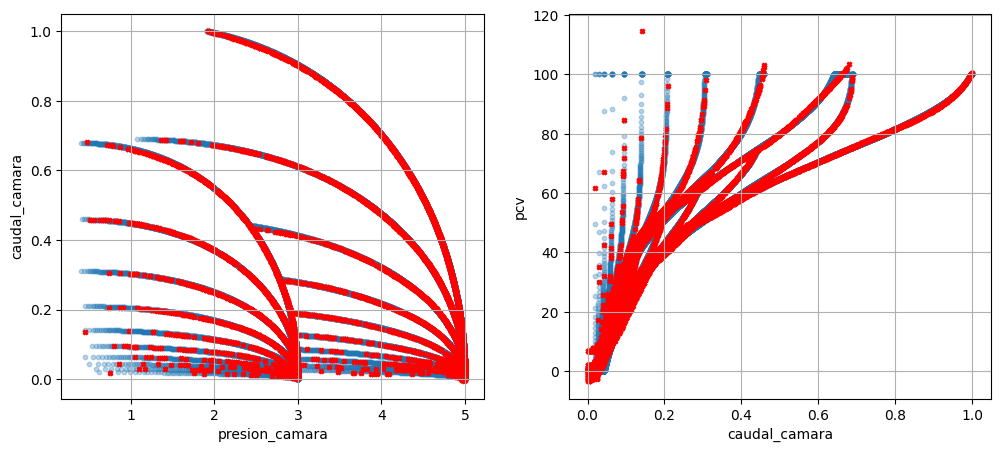

In [ ]:
metrics(modelo, scaler_X, scaler_y, X_test, y_test, "TEST")
metrics(modelo, scaler_X, scaler_y, X_blind, y_blind, "BLIND")

### Guardar NN

In [ ]:
torch.save({
    'model_state': modelo.state_dict(),
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
}, 'model_v5.pth')

### Cargar NN

In [ ]:
modelo = MLP()

url2 = 'https://raw.githubusercontent.com/leito92/EEM/main/model/model_v5.pth'
response = requests.get(url2)
response.raise_for_status()
buffer = io.BytesIO(response.content)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

checkpoint = torch.load(buffer, map_location=device, weights_only=False)
modelo.load_state_dict(checkpoint['model_state'])
modelo.eval()
scaler_X = checkpoint['scaler_X']
scaler_y = checkpoint['scaler_y']

HTTPError: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/leito92/EEM/main/modelo/model_v5.pth

### Test 2

In [ ]:
class Omni:
    def __init__(self, modelo, scaler_X, scaler_y):
        self.model = modelo
        self.model.eval()
        self.scaler_X = scaler_X
        self.scaler_y = scaler_y
        self.known_mfcs = sorted(df_final['mfc'].unique().tolist())
        self.p_min = df_final['presion_camara'].min()
        self.p_max = df_final['presion_camara'].max()
        self.known_presion_entrada = sorted(df_final['presion_entrada'].unique().tolist())

    def _predict_raw(self, presion, mfc, presion_entrada):
        """Función interna para inferencia escalar rápida."""
        X_in = pd.DataFrame([[presion, mfc, presion_entrada]], columns=['presion_camara', 'mfc', 'presion_entrada'])
        X_scaled = self.scaler_X.transform(X_in)
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_scaled)
            y_pred_scaled = self.model(X_tensor).numpy()
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)
        return y_pred[0][0], y_pred[0][1]

    def get_caudal(self, target_presion, target_presion_entrada=None):
        if target_presion_entrada is None:
            return pd.concat(
                [self.get_caudal(target_presion, pe) for pe in self.known_presion_entrada],
                ignore_index=True
            )

        resultados = []
        X_batch_np = np.column_stack((np.full(len(self.known_mfcs), target_presion),
                                      self.known_mfcs,
                                      np.full(len(self.known_mfcs), target_presion_entrada)))
        X_batch = pd.DataFrame(X_batch_np, columns=['presion_camara', 'mfc', 'presion_entrada'])
        X_scaled = self.scaler_X.transform(X_batch)

        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_scaled)
            y_pred_scaled = self.model(X_tensor).numpy()

        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)

        for i, mfc in enumerate(self.known_mfcs):
            resultados.append({
                'presion_entrada': target_presion_entrada,
                'presion_camara': target_presion,
                'caudal_camara': y_pred[i][0],
                'pcv': y_pred[i][1],
                'mfc': mfc
            })
        return pd.DataFrame(resultados)

    def get_presion(self, target_caudal, target_presion_entrada=None):
        if target_presion_entrada is None:
            return pd.concat(
                [self.get_presion(target_caudal, pe) for pe in self.known_presion_entrada],
                ignore_index=True
            )

        resultados = []
        for mfc in self.known_mfcs:
            def funcion_error(P):
                caudal_pred, _ = self._predict_raw(P, mfc, target_presion_entrada)
                return caudal_pred - target_caudal

            try:
                error_min = funcion_error(self.p_min)
                error_max = funcion_error(self.p_max)

                if np.sign(error_min) * np.sign(error_max) > 0:
                    continue

                presion_pred = brentq(funcion_error, self.p_min, self.p_max, xtol=1e-4)
                _, pcv_pred = self._predict_raw(presion_pred, mfc, target_presion_entrada)

                resultados.append({
                    'presion_entrada': target_presion_entrada,
                    'presion_camara': presion_pred,
                    'caudal_camara': target_caudal,
                    'pcv': pcv_pred,
                    'mfc': mfc
                })
            except ValueError:
                pass
        return pd.DataFrame(resultados)


    def get_interpolado(self, target_presion, target_caudal, target_presion_entrada=None):
        if target_presion_entrada is None:
          resultados = [
              self.get_interpolado(target_presion, target_caudal, pe)
              for pe in self.known_presion_entrada
          ]
          resultados = [r for r in resultados if r is not None]
          if not resultados:
              return None
          df_concat = pd.concat(resultados, ignore_index=True)
          return df_concat.loc[df_concat['mfc'].idxmax()].to_frame().T.reset_index(drop=True)

        mfc_lower, mfc_upper = None, None
        for i in range(len(self.known_mfcs) - 1):
            mfc_a = self.known_mfcs[i]
            mfc_b = self.known_mfcs[i + 1]
            caudal_a, _ = self._predict_raw(target_presion, mfc_a, target_presion_entrada)
            caudal_b, _ = self._predict_raw(target_presion, mfc_b, target_presion_entrada)

            if min(caudal_a, caudal_b) <= target_caudal <= max(caudal_a, caudal_b):
                mfc_lower = mfc_a
                mfc_upper = mfc_b
                break

        if mfc_lower is None or mfc_upper is None:
            return None

        def funcion_error(mfc_val):
            caudal_pred, _ = self._predict_raw(target_presion, mfc_val, target_presion_entrada)
            return caudal_pred - target_caudal

        mfc_interpolado = brentq(funcion_error, mfc_lower, mfc_upper, xtol=1e-4)
        _, pcv_pred = self._predict_raw(target_presion, mfc_interpolado, target_presion_entrada)

        return pd.DataFrame([{
            'presion_entrada': target_presion_entrada,
            'presion_camara': target_presion,
            'caudal_camara': target_caudal,
            'pcv': pcv_pred,
            'mfc': mfc_interpolado
        }])

In [ ]:
def draw(df_resultado):
    # Detectar régimen desde el resultado
    presiones_entrada = df_resultado['presion_entrada'].unique()

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    unique_mfcs = sorted(df_final['mfc'].unique())

    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_mfcs)))
    mfc_to_color = dict(zip(unique_mfcs, colors))

    # Filtrar df_final por presion_entrada si hay un solo régimen
    # Si hay ambos (None fue pasado), mostrar todo
    if len(presiones_entrada) == 1:
        df_fondo = df_final[df_final['presion_entrada'] == presiones_entrada[0]]
        titulo = f'presion_entrada = {presiones_entrada[0]}'
    else:
        df_fondo = df_final
        titulo = 'presion_entrada = 3 y 5'

    # 1. Gráfico Presión vs Caudal
    for mfc_value in unique_mfcs:
        df_mfc = df_fondo[df_fondo['mfc'] == mfc_value]
        ax[0].scatter(df_mfc['presion_camara'], df_mfc['caudal_camara'],
                     color=mfc_to_color[mfc_value], alpha=0.3, s=10, label=f'MFC: {mfc_value}')

    ax[0].scatter(df_resultado['presion_camara'], df_resultado['caudal_camara'],
                 marker="X", color="red", s=25, edgecolors='black', zorder=5)
    ax[0].set_xlabel('presion_camara')
    ax[0].set_ylabel('caudal_camara')
    ax[0].set_title(titulo)
    ax[0].grid(True, alpha=0.3)

    # 2. Gráfico Caudal vs PCV
    for mfc_value in unique_mfcs:
        df_mfc = df_fondo[df_fondo['mfc'] == mfc_value]
        ax[1].scatter(df_mfc['caudal_camara'], df_mfc['pcv'],
                     color=mfc_to_color[mfc_value], alpha=0.3, s=10)

    ax[1].scatter(df_resultado['caudal_camara'], df_resultado['pcv'],
                 marker="X", color="red", s=25, edgecolors='black', zorder=5)
    ax[1].set_xlabel('caudal_camara')
    ax[1].set_ylabel('pcv')
    ax[1].set_title(titulo)
    ax[1].grid(True, alpha=0.3)

    handles, labels = ax[0].get_legend_handles_labels()
    leg = fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
                     title="MFCs", scatterpoints=1)

    for lh in leg.legend_handles:
        lh.set_alpha(1.0)
        lh.set_sizes([60])

    plt.tight_layout()
    plt.show()

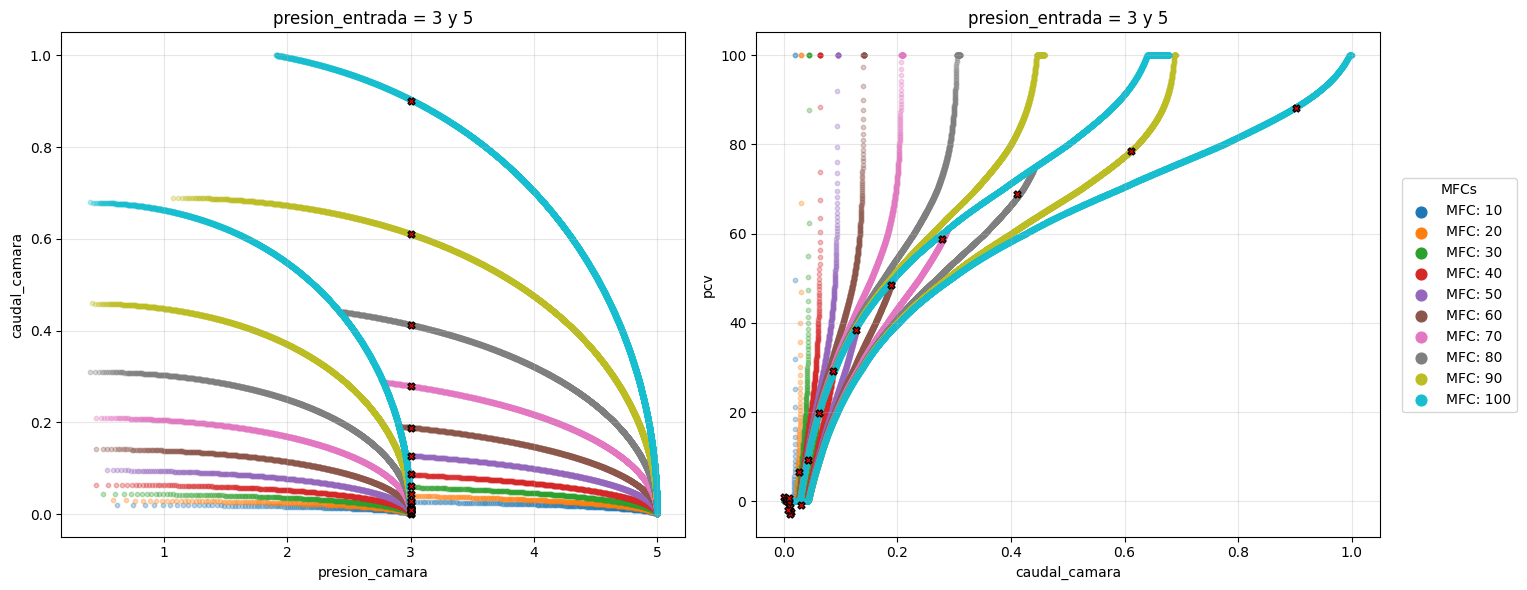

 presion_entrada  presion_camara  caudal_camara       pcv  mfc
               3               3       0.001018  1.037472   10
               3               3       0.003085  0.278032   20
               3               3       0.006009 -0.013395   30
               3               3       0.009043 -0.373693   40
               3               3       0.011641 -1.240035   50
               3               3       0.012830 -2.340290   60
               3               3       0.011369 -2.791736   70
               3               3       0.008206 -1.871431   80
               3               3       0.008796  0.695765   90
               3               3       0.026222  6.600743  100
               5               3       0.029428 -0.875086   10
               5               3       0.043050  9.253347   20
               5               3       0.061241 19.749105   30
               5               3       0.086873 29.105886   40
               5               3       0.126668 38.3192

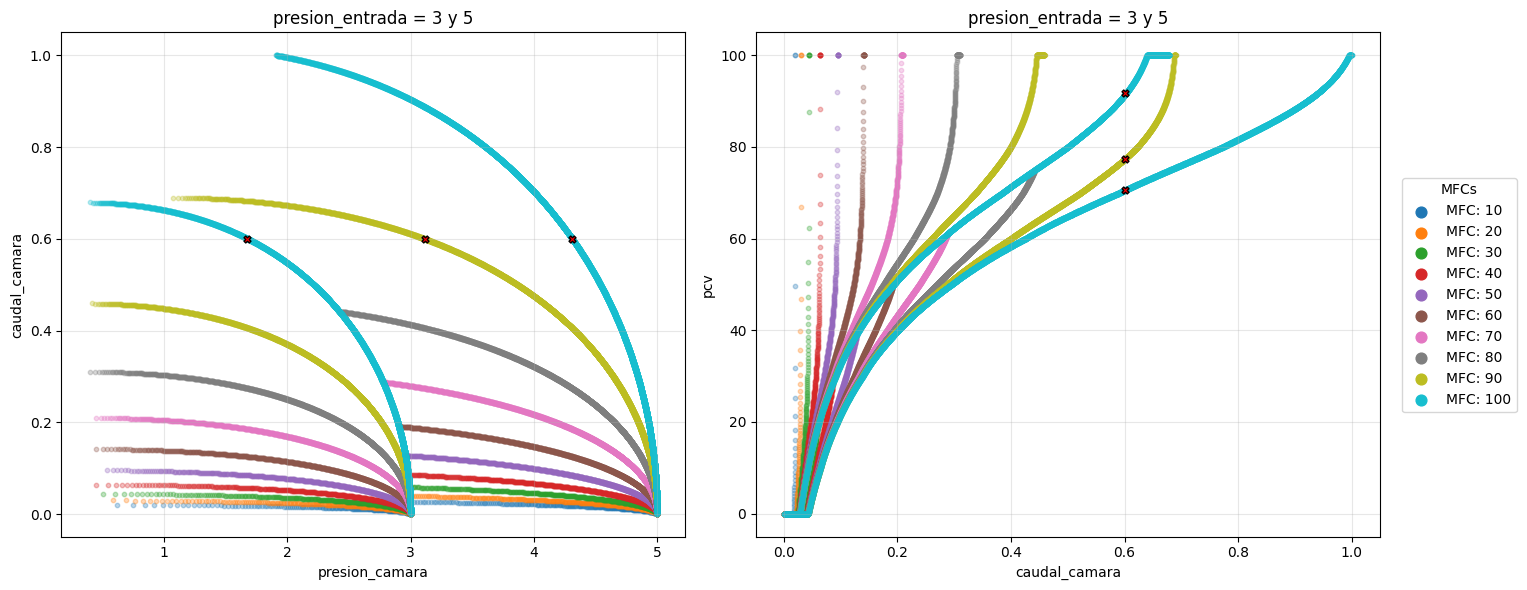

 presion_entrada  presion_camara  caudal_camara       pcv  mfc
               3        1.671329            0.6 91.865799  100
               5        3.114153            0.6 77.327003   90
               5        4.307398            0.6 70.537659  100



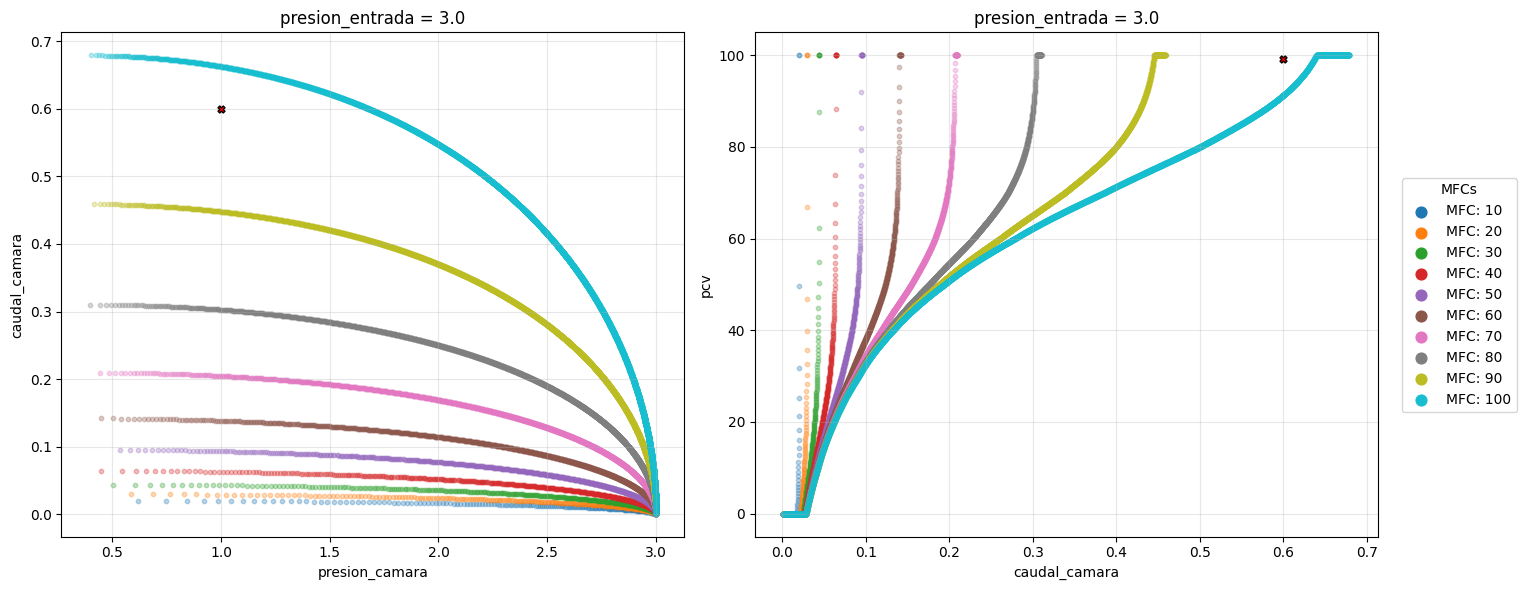

 presion_entrada  presion_camara  caudal_camara       pcv       mfc
             3.0             1.0            0.6 99.186592 97.476713


In [ ]:
ai = Omni(modelo, scaler_X, scaler_y)

presion = 3
df_resultado = ai.get_caudal(presion)
draw(df_resultado)
print(f"{df_resultado.to_string(index=False)}\n")

caudal = 0.6
df_resultado = ai.get_presion(caudal)
draw(df_resultado)
print(f"{df_resultado.to_string(index=False)}\n")

presion = 1
caudal = 0.6
df_resultado = ai.get_interpolado(presion, caudal)
draw(df_resultado)
if df_resultado is not None:
    print(f"{df_resultado.to_string(index=False)}")
else:
    print(f"No se encontró interpolación para presion={presion}, caudal={caudal}")

---
## v4
Contexto:
> * Feature: presión en cámara, caudal en cámara
> * Targets: PCV, MFC
> * predecir dentro del área (entre 2 curvas)

Solución:
> Mismo modelo utilizado en v3 pero predice a partir de 1 par de P-Q.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.optimize import brentq
import requests
import io

### Dataset

In [ ]:
url = 'https://raw.githubusercontent.com/leito92/EEM/main/data/v2.csv'
df = pd.read_csv(url, sep=';')
display(df)

,#,presion_entrada,mfc,pcv,caudal_camara,presion_camara
0,Case 1,5,100,"99,99",1,"1,909"
1,Case 2,5,100,"99,99","0,9999","1,911"
2,Case 3,5,100,"99,99","0,9998","1,913"
3,Case 4,5,100,"99,99","0,9997","1,915"
4,Case 5,5,100,"99,99","0,9996","1,917"
...,...,...,...,...,...,...
30385,Case 99906,5,10,0,"0,0014","4,996"
30386,Case 99907,5,10,0,"0,0013","4,997"
30387,Case 99908,5,10,0,"0,0012","4,997"
30388,Case 99909,5,10,0,"0,0011","4,998"


In [ ]:
# Convertir columnas con comas a formato numérico con puntos
columns_to_convert = ['pcv', 'caudal_camara', 'presion_camara']
for col in columns_to_convert:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

### Modelo NN

In [ ]:
class MLP(nn.Module): # Multilayer Perceptron
    def __init__(self):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
modelo = MLP()

url2 = 'https://raw.githubusercontent.com/leito92/EEM/main/model/model_v3.pth'
response = requests.get(url2)
response.raise_for_status()
buffer = io.BytesIO(response.content)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

checkpoint = torch.load(buffer, map_location=device, weights_only=False)
modelo.load_state_dict(checkpoint['model_state'])
modelo.eval()
scaler_X = checkpoint['scaler_X']
scaler_y = checkpoint['scaler_y']

In [ ]:
class Omni:
    def __init__(self, modelo, scaler_X, scaler_y):
        self.model = modelo
        self.model.eval()
        self.scaler_X = scaler_X
        self.scaler_y = scaler_y
        self.known_mfcs = sorted(df['mfc'].unique().tolist())
        self.p_min = df['presion_camara'].min()
        self.p_max = df['presion_camara'].max()

    def _predict_raw(self, presion, mfc):
        """Función interna para inferencia escalar rápida."""
        X_in = pd.DataFrame([[presion, mfc]], columns=['presion_camara', 'mfc'])
        X_scaled = self.scaler_X.transform(X_in)
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_scaled)
            y_pred_scaled = self.model(X_tensor).numpy()
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)
        return y_pred[0][0], y_pred[0][1]

    def get_caudal(self, target_presion):
        resultados = []
        X_batch_np = np.column_stack((np.full(len(self.known_mfcs), target_presion), self.known_mfcs))
        X_batch = pd.DataFrame(X_batch_np, columns=['presion_camara', 'mfc'])
        X_scaled = self.scaler_X.transform(X_batch)

        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_scaled)
            y_pred_scaled = self.model(X_tensor).numpy()

        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)

        for i, mfc in enumerate(self.known_mfcs):
            resultados.append({
                'presion_camara': target_presion,
                'caudal_camara': y_pred[i][0],
                'pcv': y_pred[i][1],
                'mfc': mfc
            })
        return pd.DataFrame(resultados)

    def get_presion(self, target_caudal):
        resultados = []
        for mfc in self.known_mfcs:
            def funcion_error(P):
                caudal_pred, _ = self._predict_raw(P, mfc)
                return caudal_pred - target_caudal

            try:
                error_min = funcion_error(self.p_min)
                error_max = funcion_error(self.p_max)

                if np.sign(error_min) * np.sign(error_max) > 0:
                    continue

                presion_pred = brentq(funcion_error, self.p_min, self.p_max, xtol=1e-4)
                _, pcv_pred = self._predict_raw(presion_pred, mfc)

                resultados.append({
                    'caudal_camara': target_caudal,
                    'presion_camara': presion_pred,
                    'pcv': pcv_pred,
                    'mfc': mfc
                })
            except ValueError:
                pass
        return pd.DataFrame(resultados)


    def get_interpolado(self, target_presion, target_caudal):
        mfc_lower, mfc_upper = None, None
        for i in range(len(self.known_mfcs) - 1):
            mfc_a = self.known_mfcs[i]
            mfc_b = self.known_mfcs[i + 1]
            caudal_a, _ = self._predict_raw(target_presion, mfc_a)
            caudal_b, _ = self._predict_raw(target_presion, mfc_b)

            if min(caudal_a, caudal_b) <= target_caudal <= max(caudal_a, caudal_b):
                mfc_lower = mfc_a
                mfc_upper = mfc_b
                break

        if mfc_lower is None or mfc_upper is None:
            return None

        def funcion_error(mfc_val):
            caudal_pred, _ = self._predict_raw(target_presion, mfc_val)
            return caudal_pred - target_caudal

        mfc_interpolado = brentq(funcion_error, mfc_lower, mfc_upper, xtol=1e-4)
        _, pcv_pred = self._predict_raw(target_presion, mfc_interpolado)

        resultado = {
            'presion_camara': target_presion,
            'caudal_camara': target_caudal,
            'pcv': pcv_pred,
            'mfc': mfc_interpolado
        }
        return pd.DataFrame([resultado])

In [ ]:
def draw(df_resultado):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    unique_mfcs = sorted(df['mfc'].unique())

    # Colores consistentes y distintos para cada MFC
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_mfcs)))
    mfc_to_color = dict(zip(unique_mfcs, colors))

    # 1. Gráfico Presión vs Caudal
    for mfc_value in unique_mfcs:
        df_mfc = df[df['mfc'] == mfc_value]
        ax[0].scatter(df_mfc['presion_camara'], df_mfc['caudal_camara'],
                     color=mfc_to_color[mfc_value], alpha=0.3, s=10, label=f'MFC: {mfc_value}')

    ax[0].scatter(df_resultado['presion_camara'], df_resultado['caudal_camara'],
                 marker="X", color="red", s=25, edgecolors='black')
    ax[0].set_xlabel('presion_camara')
    ax[0].set_ylabel('caudal_camara')
    ax[0].grid(True, alpha=0.3)

    # 2. Gráfico Caudal vs PCV
    for mfc_value in unique_mfcs:
        df_mfc = df[df['mfc'] == mfc_value]
        ax[1].scatter(df_mfc['caudal_camara'], df_mfc['pcv'],
                     color=mfc_to_color[mfc_value], alpha=0.3, s=10)

    ax[1].scatter(df_resultado['caudal_camara'], df_resultado['pcv'],
                 marker="X", color="red", s=25, edgecolors='black')
    ax[1].set_xlabel('caudal_camara')
    ax[1].set_ylabel('pcv')
    ax[1].grid(True, alpha=0.3)

    handles, labels = ax[0].get_legend_handles_labels()
    leg = fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
                     title="MFCs", scatterpoints=1)

    for lh in leg.legend_handles:
        lh.set_alpha(1.0)
        lh.set_sizes([60])

    plt.tight_layout()
    plt.show()

### Test

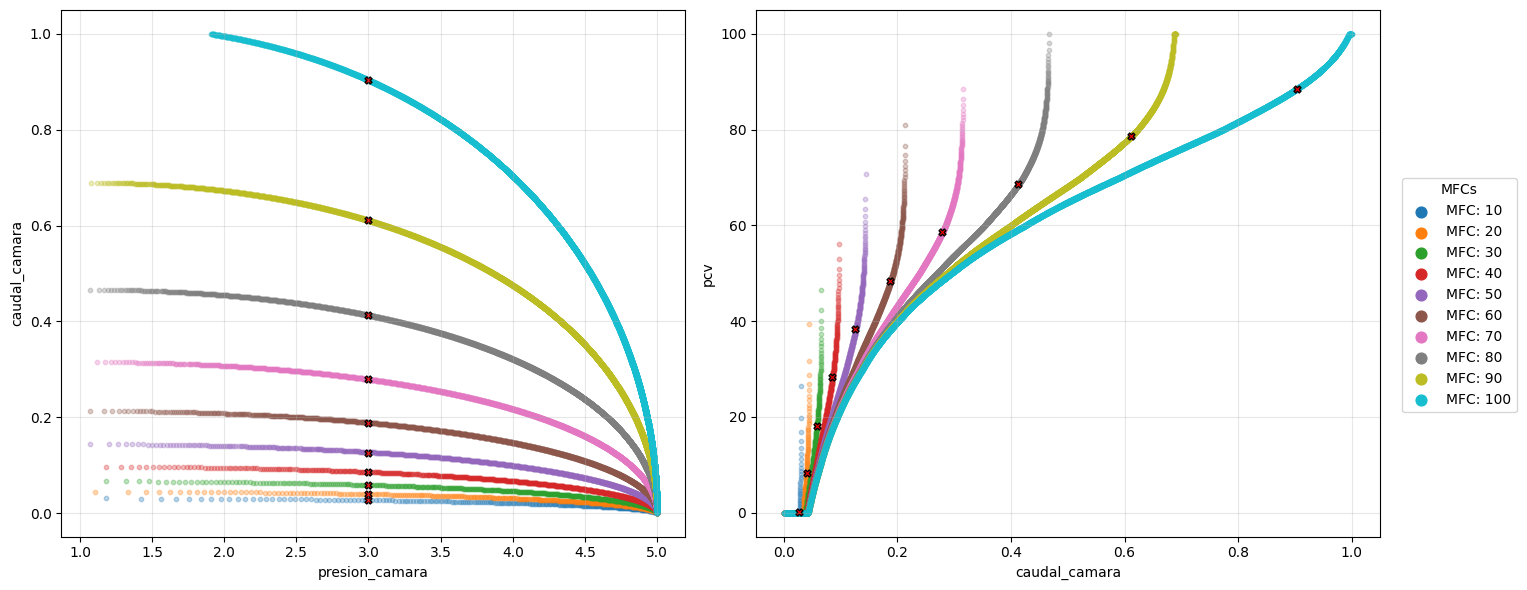

 presion_camara  caudal_camara       pcv  mfc
              3       0.026522  0.042386   10
              3       0.040077  8.329491   20
              3       0.058265 18.045589   30
              3       0.085375 28.355858   40
              3       0.126206 38.460930   50
              3       0.187795 48.492519   60
              3       0.279016 58.571392   70
              3       0.412432 68.610504   80
              3       0.611115 78.652664   90
              3       0.903328 88.596458  100



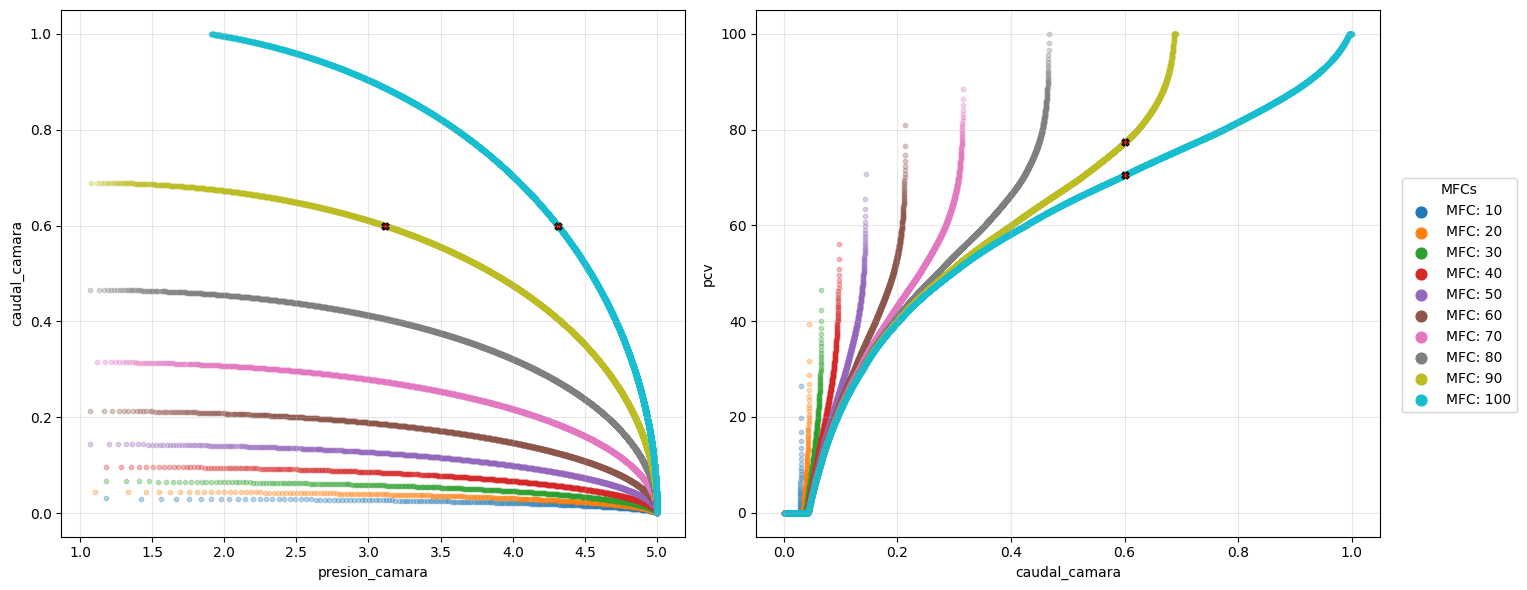

 caudal_camara  presion_camara       pcv  mfc
           0.6        3.115784 77.410988   90
           0.6        4.310372 70.605598  100



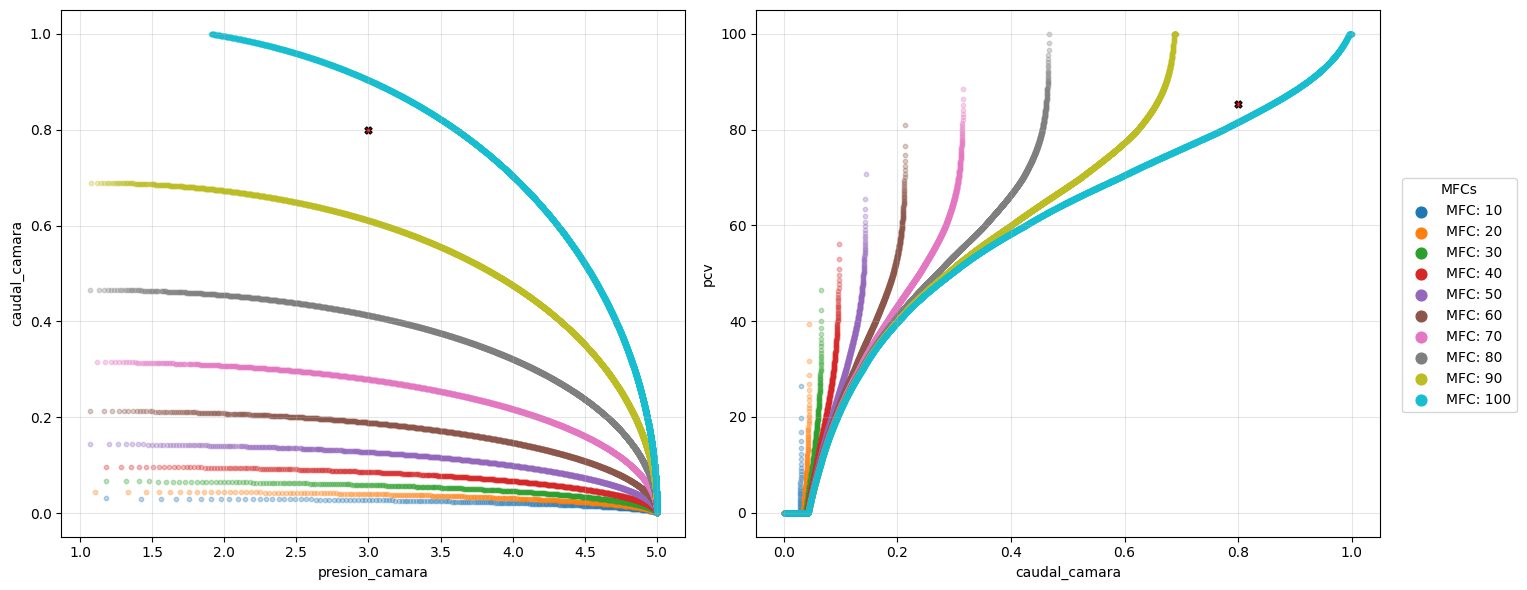

 presion_camara  caudal_camara       pcv       mfc
              3            0.8 85.433701 96.811372


In [ ]:
ai = Omni(modelo, scaler_X, scaler_y)

presion = 3
df_resultado = ai.get_caudal(presion)
draw(df_resultado)
print(f"{df_resultado.to_string(index=False)}\n")

caudal = 0.6
df_resultado = ai.get_presion(caudal)
draw(df_resultado)
print(f"{df_resultado.to_string(index=False)}\n")

presion = 3
caudal = 0.8
df_resultado = ai.get_interpolado(presion, caudal)
draw(df_resultado)
print(f"{df_resultado.to_string(index=False)}")

---
## v3
Contexto:
> * N resultados por cada MFC
> * 30390 registros

Solución:
> ANN porque permite interpolar. Modelo elegido: MLP, por su rapidez.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from scipy.optimize import brentq

### Dataset

In [ ]:
url = 'https://raw.githubusercontent.com/leito92/EEM/main/data/v2.csv'
df = pd.read_csv(url, sep=';')
display(df)

,#,presion_entrada,mfc,pcv,caudal_camara,presion_camara
0,Case 1,5,100,"99,99",1,"1,909"
1,Case 2,5,100,"99,99","0,9999","1,911"
2,Case 3,5,100,"99,99","0,9998","1,913"
3,Case 4,5,100,"99,99","0,9997","1,915"
4,Case 5,5,100,"99,99","0,9996","1,917"
...,...,...,...,...,...,...
30385,Case 99906,5,10,0,"0,0014","4,996"
30386,Case 99907,5,10,0,"0,0013","4,997"
30387,Case 99908,5,10,0,"0,0012","4,997"
30388,Case 99909,5,10,0,"0,0011","4,998"


In [ ]:
# Convertir columnas con comas a formato numérico con puntos
columns_to_convert = ['pcv', 'caudal_camara', 'presion_camara']
for col in columns_to_convert:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

### Gráfico

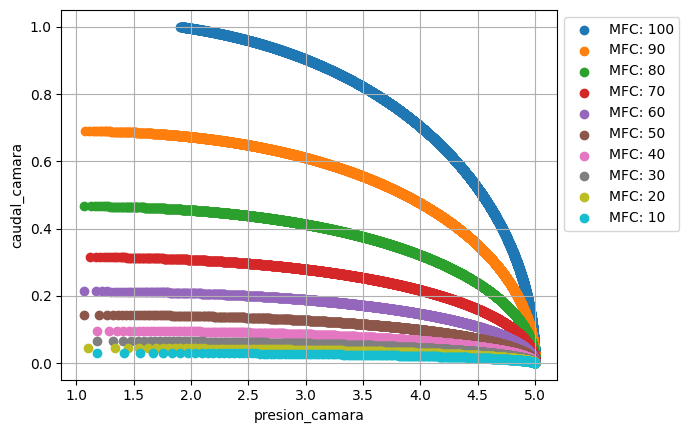

In [ ]:
plt.figure()

for mfc_value in df['mfc'].unique():
    df_mfc = df[df['mfc'] == mfc_value]
    plt.scatter(df_mfc['presion_camara'], df_mfc['caudal_camara'], label=f'MFC: {mfc_value}')

plt.xlabel('presion_camara')
plt.ylabel('caudal_camara')
plt.grid(True)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

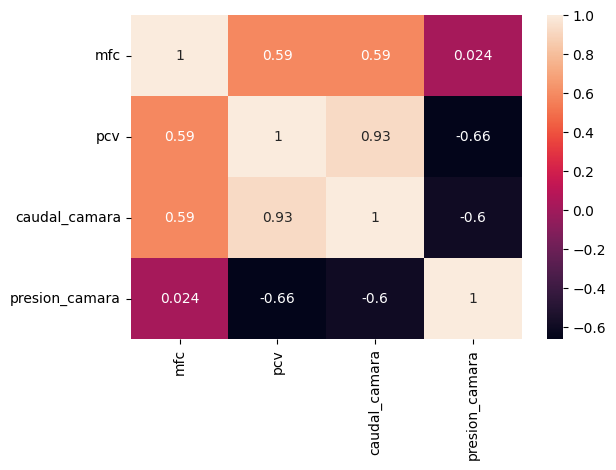

In [ ]:
matriz_corr = df.drop(columns=['#', 'presion_entrada']).corr()
sns.heatmap(
    matriz_corr,
    annot=True
)
plt.tight_layout()
plt.show()

### Modelo NN

In [ ]:
def prepare_data(df):
  X = df[["presion_camara", "mfc"]]
  y = df[["caudal_camara","pcv"]]

  X_rest, X_blind, y_rest, y_blind = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
  )

  X_train, X_test, y_train, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.20,
    random_state=42
  )

  total = len(X)
  print(f"PARTICIONES DE DATOS:")
  print(f"Total: {total} pts (100%)")
  print(f"Train: {len(X_train)} pts ({len(X_train)/total*100:.1f}%)")
  print(f"Test: {len(X_test)} pts ({len(X_test)/total*100:.1f}%)")
  print(f"Blind: {len(X_blind)} pts ({len(X_blind)/total*100:.1f}%)")

  return X_train, X_test, X_blind, y_train, y_test, y_blind

In [ ]:
X_train, X_test, X_blind, y_train, y_test, y_blind = prepare_data(df)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

PARTICIONES DE DATOS:
Total: 30390 pts (100%)
Train: 21880 pts (72.0%)
Test: 5471 pts (18.0%)
Blind: 3039 pts (10.0%)


In [ ]:
tensor_X_train = torch.FloatTensor(X_train_scaled)
tensor_y_train = torch.FloatTensor(y_train_scaled)
dataset_train = TensorDataset(tensor_X_train, tensor_y_train)
loader_train = DataLoader(dataset_train, batch_size=256, shuffle=True)

In [ ]:
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

tensor_X_test = torch.FloatTensor(X_test_scaled)
tensor_y_test = torch.FloatTensor(y_test_scaled)

dataset_test = TensorDataset(tensor_X_test, tensor_y_test)
loader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

In [ ]:
class MLP(nn.Module): # Multilayer Perceptron
    def __init__(self):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
modelo = MLP()
criterio = nn.MSELoss()
optimizador = optim.AdamW(modelo.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador,
    mode='min', # minimizar loss
    patience=10,
    factor=0.5 # reducir lr a la mitad
)

epochs = 300
historial_train = []
historial_val = []

for epoch in range(epochs):
    modelo.train()
    loss_total = 0
    for batch_X, batch_y in loader_train:
        optimizador.zero_grad()
        preds = modelo(batch_X)
        loss = criterio(preds, batch_y)
        loss.backward()
        optimizador.step()
        loss_total += loss.item()
    loss_train = loss_total / len(loader_train)
    historial_train.append(loss_train)

    modelo.eval()
    loss_val_total = 0
    with torch.no_grad():
        for batch_X, batch_y in loader_test:
            preds_val = modelo(batch_X)
            loss_val_total += criterio(preds_val, batch_y).item()
    loss_val = loss_val_total / len(loader_test)
    historial_val.append(loss_val)

    scheduler.step(loss_train)  # ajusta LR

    if epoch % 10 == 0:
        lr_actual = optimizador.param_groups[0]['lr']
        print(f"Época [{epoch}/{epochs}] -> Loss_Train: {loss_train:.6f} | Loss_Val: {loss_val:.6f} | LR: {lr_actual:.6f}")

Época [0/300] -> Loss_Train: 0.038658 | Loss_Val: 0.015424 | LR: 0.001000
Época [10/300] -> Loss_Train: 0.001771 | Loss_Val: 0.001559 | LR: 0.001000
Época [20/300] -> Loss_Train: 0.000713 | Loss_Val: 0.000658 | LR: 0.001000
Época [30/300] -> Loss_Train: 0.000528 | Loss_Val: 0.000368 | LR: 0.001000
Época [40/300] -> Loss_Train: 0.000281 | Loss_Val: 0.000297 | LR: 0.001000
Época [50/300] -> Loss_Train: 0.000209 | Loss_Val: 0.000252 | LR: 0.001000
Época [60/300] -> Loss_Train: 0.000282 | Loss_Val: 0.000190 | LR: 0.001000
Época [70/300] -> Loss_Train: 0.000203 | Loss_Val: 0.000457 | LR: 0.001000
Época [80/300] -> Loss_Train: 0.000151 | Loss_Val: 0.000125 | LR: 0.000500
Época [90/300] -> Loss_Train: 0.000118 | Loss_Val: 0.000106 | LR: 0.000500
Época [100/300] -> Loss_Train: 0.000114 | Loss_Val: 0.000147 | LR: 0.000500
Época [110/300] -> Loss_Train: 0.000115 | Loss_Val: 0.000164 | LR: 0.000250
Época [120/300] -> Loss_Train: 0.000099 | Loss_Val: 0.000099 | LR: 0.000250
Época [130/300] -> Loss

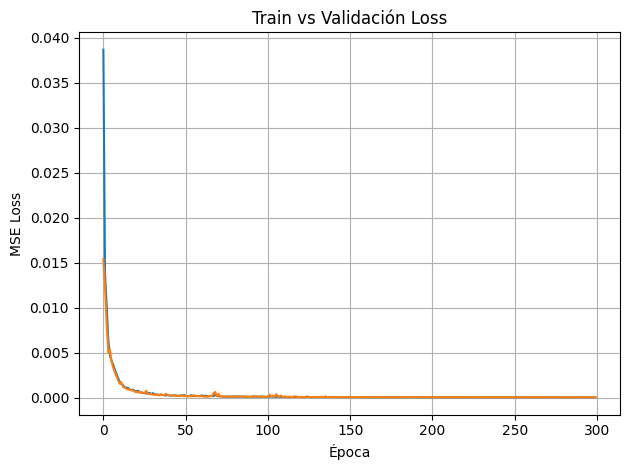

In [ ]:
plt.figure()
plt.plot(historial_train, label='Loss Train')
plt.plot(historial_val, label='Loss Val')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('Train vs Validación Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

### Test

In [ ]:
def metrics(modelo, scaler_X, scaler_y, X_eval, y_eval, nombre_set):
    modelo.eval()

    # Escalar entradas y predecir
    X_eval_scaled = scaler_X.transform(X_eval)
    with torch.no_grad():
        tensor_X = torch.FloatTensor(X_eval_scaled)
        y_pred_scaled = modelo(tensor_X).numpy()

    # Desescalar predicciones a unidades físicas reales
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    # Separar variables para evaluación individual
    caudal_real, caudal_pred = y_eval.iloc[:, 0], y_pred[:, 0]
    pcv_real, pcv_pred = y_eval.iloc[:, 1], y_pred[:, 1]

    # Métricas Caudal
    mse_q = mean_squared_error(caudal_real, caudal_pred)
    rmse_q = np.sqrt(mse_q)
    r2_q = r2_score(caudal_real, caudal_pred)

    # Métricas PCV
    mse_v = mean_squared_error(pcv_real, pcv_pred)
    rmse_v = np.sqrt(mse_v)
    r2_v = r2_score(pcv_real, pcv_pred)

    # Resultados
    print(f"\nSet: {nombre_set}")
    print(f"Variable: CAUDAL EN CÁMARA")
    print(f"- MSE: {mse_q:.6f}")
    print(f"- RMSE: {rmse_q:.6f}")
    print(f"- R²: {r2_q:.4f}")
    print(f"Variable: PCV")
    print(f"- MSE: {mse_v:.6f}")
    print(f"- RMSE: {rmse_v:.6f}")
    print(f"- R²: {r2_v:.4f}")

    resultado = pd.DataFrame({
      'caudal_camara_real': caudal_real.values,
      'caudal_camara_pred': caudal_pred.round(4),
      'pcv_real':           pcv_real.values,
      'pcv_pred':           pcv_pred.round(4)
    })
    display(resultado)

    fig, ax = plt.subplots(1,2, figsize=(12, 5))
    ax[0].scatter(df["presion_camara"], df["caudal_camara"], alpha=0.3, s=10)
    ax[0].scatter(
        X_eval['presion_camara'], y_pred[:, 0],
        marker="X", color="red", s=10
    )
    ax[0].set_xlabel('presion_camara')
    ax[0].set_ylabel('caudal_camara')
    ax[0].grid(True)

    ax[1].scatter(df["caudal_camara"], df["pcv"], alpha=0.3, s=10)
    ax[1].scatter(
        y_eval['caudal_camara'], y_pred[:, 1],
        marker="X", color="red", s=10
    )
    ax[1].set_xlabel('caudal_camara')
    ax[1].set_ylabel('pcv')
    ax[1].grid(True)

    plt.show()


Set: TEST
Variable: CAUDAL EN CÁMARA
- MSE: 0.000012
- RMSE: 0.003533
- R²: 0.9998
Variable: PCV
- MSE: 1.132052
- RMSE: 1.063979
- R²: 0.9985


,caudal_camara_real,caudal_camara_pred,pcv_real,pcv_pred
0,0.3052,0.3069,51.83,51.905399
1,0.0041,0.0149,0.00,-3.233800
2,0.0428,0.0412,0.00,4.391900
3,0.0875,0.0843,18.60,17.162600
4,0.1796,0.1816,36.97,37.033199
...,...,...,...,...
5466,0.6382,0.6406,82.27,82.086197
5467,0.5936,0.5949,76.65,76.798897
5468,0.2992,0.2990,53.59,53.057598
5469,0.2118,0.2040,66.80,66.952301


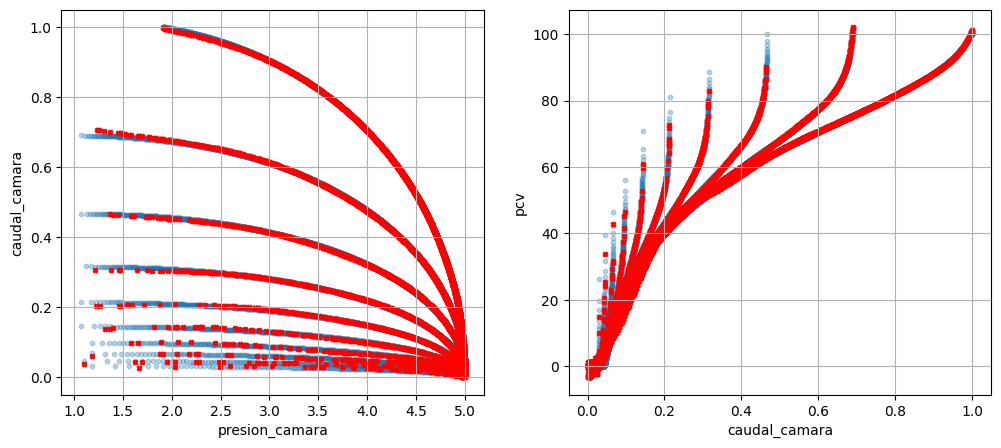


Set: BLIND
Variable: CAUDAL EN CÁMARA
- MSE: 0.000012
- RMSE: 0.003480
- R²: 0.9998
Variable: PCV
- MSE: 1.283263
- RMSE: 1.132812
- R²: 0.9983


,caudal_camara_real,caudal_camara_pred,pcv_real,pcv_pred
0,0.1976,0.1990,39.77,39.664700
1,0.7621,0.7628,79.36,79.435303
2,0.1625,0.1619,34.35,33.193901
3,0.2882,0.2884,52.28,51.790501
4,0.0578,0.0514,7.28,7.301000
...,...,...,...,...
3034,0.2095,0.2103,41.41,41.095001
3035,0.9731,0.9687,95.66,95.592300
3036,0.4361,0.4352,73.41,73.188698
3037,0.0699,0.0665,17.58,17.512899


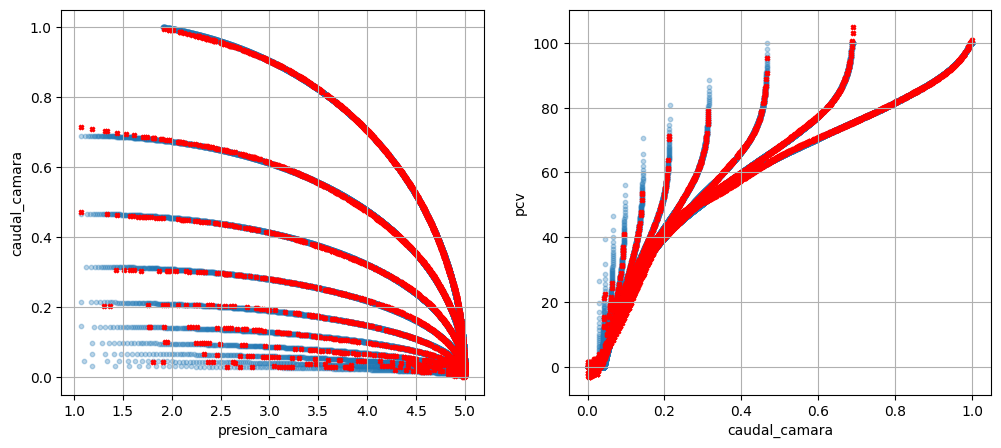

In [ ]:
metrics(modelo, scaler_X, scaler_y, X_test, y_test, "TEST")
metrics(modelo, scaler_X, scaler_y, X_blind, y_blind, "BLIND")

### Guardar NN

In [ ]:
torch.save({
    'model_state': modelo.state_dict(),
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
}, 'model_v3.pth')

### Cargar NN

In [ ]:
modelo = MLP()

url2 = 'https://raw.githubusercontent.com/leito92/EEM/main/model/model_v3.pth'
response = requests.get(url2)
response.raise_for_status()
buffer = io.BytesIO(response.content)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

checkpoint = torch.load(buffer, map_location=device, weights_only=False)
modelo.load_state_dict(checkpoint['model_state'])
modelo.eval()
scaler_X = checkpoint['scaler_X']
scaler_y = checkpoint['scaler_y']

### Test 2

In [ ]:
class Omni:
    def __init__(self, modelo, scaler_X, scaler_y):
        self.model = modelo
        self.model.eval()
        self.scaler_X = scaler_X
        self.scaler_y = scaler_y
        self.known_mfcs = sorted(df['mfc'].unique().tolist())
        self.p_min = df['presion_camara'].min()
        self.p_max = df['presion_camara'].max()

    def _predict_raw(self, presion, mfc):
        """Función interna para inferencia escalar rápida."""
        X_in = pd.DataFrame([[presion, mfc]], columns=['presion_camara', 'mfc'])
        X_scaled = self.scaler_X.transform(X_in)
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_scaled)
            y_pred_scaled = self.model(X_tensor).numpy()
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)
        return y_pred[0][0], y_pred[0][1]

    def get_caudal(self, target_presion):
        resultados = []
        X_batch_np = np.column_stack((np.full(len(self.known_mfcs), target_presion), self.known_mfcs))
        X_batch = pd.DataFrame(X_batch_np, columns=['presion_camara', 'mfc'])
        X_scaled = self.scaler_X.transform(X_batch)

        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_scaled)
            y_pred_scaled = self.model(X_tensor).numpy()

        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)

        for i, mfc in enumerate(self.known_mfcs):
            resultados.append({
                'presion_camara': target_presion,
                'caudal_camara': y_pred[i][0],
                'pcv': y_pred[i][1],
                'mfc': mfc,
            })
        return pd.DataFrame(resultados)

    def get_presion(self, target_caudal):
        resultados = []
        for mfc in self.known_mfcs:
            def funcion_error(P):
                caudal_pred, _ = self._predict_raw(P, mfc)
                return caudal_pred - target_caudal

            try:
                error_min = funcion_error(self.p_min)
                error_max = funcion_error(self.p_max)

                if np.sign(error_min) * np.sign(error_max) > 0:
                    continue

                presion_pred = brentq(funcion_error, self.p_min, self.p_max, xtol=1e-4)
                _, pcv_pred = self._predict_raw(presion_pred, mfc)

                resultados.append({
                    'caudal_camara': target_caudal,
                    'presion_camara': presion_pred,
                    'pcv': pcv_pred,
                    'mfc': mfc,
                })
            except ValueError:
                pass
        return pd.DataFrame(resultados)

In [ ]:
def draw(df_resultado):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    unique_mfcs = sorted(df['mfc'].unique())

    # Colores consistentes y distintos para cada MFC
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_mfcs)))
    mfc_to_color = dict(zip(unique_mfcs, colors))

    # 1. Gráfico Presión vs Caudal
    for mfc_value in unique_mfcs:
        df_mfc = df[df['mfc'] == mfc_value]
        ax[0].scatter(df_mfc['presion_camara'], df_mfc['caudal_camara'],
                     color=mfc_to_color[mfc_value], alpha=0.3, s=10, label=f'MFC: {mfc_value}')

    ax[0].scatter(df_resultado['presion_camara'], df_resultado['caudal_camara'],
                 marker="X", color="red", s=25, edgecolors='black')
    ax[0].set_xlabel('presion_camara')
    ax[0].set_ylabel('caudal_camara')
    ax[0].grid(True, alpha=0.3)

    # 2. Gráfico Caudal vs PCV
    for mfc_value in unique_mfcs:
        df_mfc = df[df['mfc'] == mfc_value]
        ax[1].scatter(df_mfc['caudal_camara'], df_mfc['pcv'],
                     color=mfc_to_color[mfc_value], alpha=0.3, s=10)

    ax[1].scatter(df_resultado['caudal_camara'], df_resultado['pcv'],
                 marker="X", color="red", s=25, edgecolors='black')
    ax[1].set_xlabel('caudal_camara')
    ax[1].set_ylabel('pcv')
    ax[1].grid(True, alpha=0.3)

    handles, labels = ax[0].get_legend_handles_labels()
    leg = fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
                     title="MFCs", scatterpoints=1)

    for lh in leg.legend_handles:
        lh.set_alpha(1.0)
        lh.set_sizes([60])

    plt.tight_layout()
    plt.show()

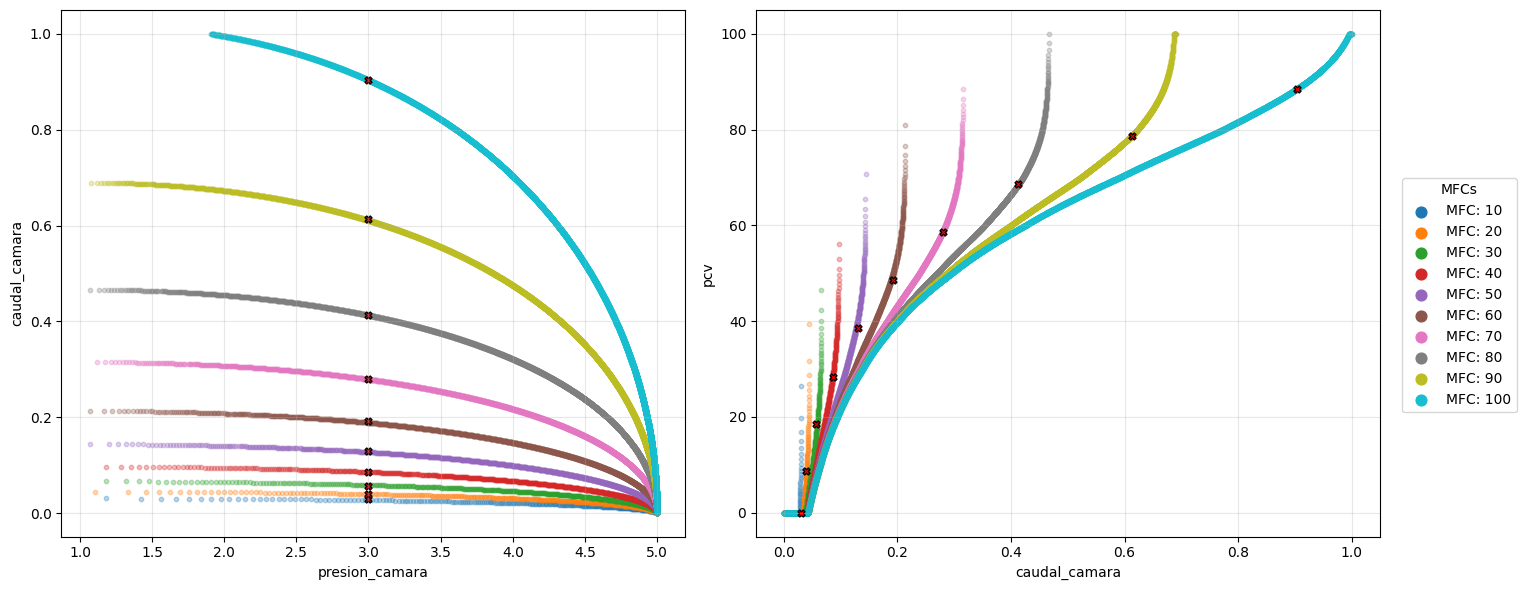

 presion_camara  caudal_camara       pcv  mfc
              3       0.029480 -0.011483   10
              3       0.039069  8.662603   20
              3       0.056683 18.412384   30
              3       0.086182 28.426495   40
              3       0.130152 38.587780   50
              3       0.191893 48.678188   60
              3       0.280148 58.635700   70
              3       0.412527 68.603554   80
              3       0.612936 78.598595   90
              3       0.903512 88.428192  100



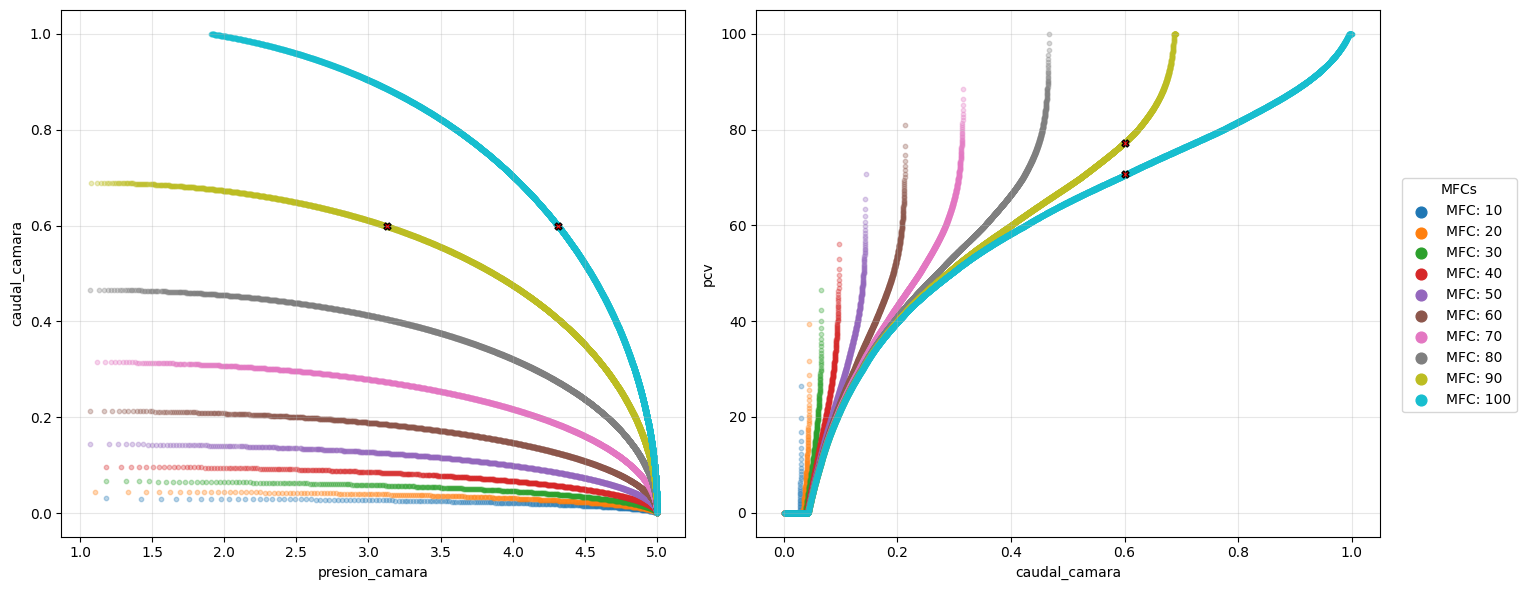

 caudal_camara  presion_camara       pcv  mfc
           0.6        3.129349 77.289230   90
           0.6        4.312242 70.736603  100


In [ ]:
ai = Omni(modelo, scaler_X, scaler_y)

presion = 3
df_resultado = ai.get_caudal(presion)
draw(df_resultado)
print(f"{df_resultado.to_string(index=False)}\n")

caudal = 0.6
df_resultado = ai.get_presion(caudal)
draw(df_resultado)
print(f"{df_resultado.to_string(index=False)}")


---
## v2
Contexto:
> * Feature: presión en cámara/caudal en cámara
> * Targets: caudal en cámara/presión en cámara, PCV
> * 544 registros

Solución:
> Mismo modelo utilizado en v1 x2, 1 para cada escenario.

Se utiliza "GridSearchCV" para automatizar la búsqueda de hiperparámetros.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### Dataset

In [ ]:
url = 'https://raw.githubusercontent.com/leito92/EEM/main/data/v1.csv'
df = pd.read_csv(url, sep=';')
display(df)

,#,presion_entrada,mfc,pcv,caudal_camara,presion_camara
0,Case 255,5,90,100,"0,746","1,112"
1,Case 256,5,90,100,"0,745","1,272"
2,Case 257,5,90,100,"0,744","1,363"
3,Case 258,5,90,100,"0,743","1,433"
4,Case 259,5,90,100,"0,742","1,493"
...,...,...,...,...,...,...
539,Case 897,5,90,"36,49","0,104","4,965"
540,Case 898,5,90,"36,37","0,103","4,966"
541,Case 899,5,90,"36,25","0,102","4,967"
542,Case 900,5,90,"36,13","0,101","4,967"


In [ ]:
# Convertir columnas con comas a formato numérico con puntos
columns_to_convert = ['pcv', 'caudal_camara', 'presion_camara']
for col in columns_to_convert:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

### Modelo ML

In [ ]:
FEATURES = {
    "presion_camara": ["caudal_camara", "pcv"],
    "caudal_camara":  ["presion_camara", "pcv"],
}

In [ ]:
def prepare_data(df, feature):
  targets = FEATURES[feature]

  X = df[[feature]]
  y = df[targets]

  X_rest, X_blind, y_rest, y_blind = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
  )

  X_train, X_test, y_train, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.20,
    random_state=42
  )

  return X_train, X_test, X_blind, y_train, y_test, y_blind

In [ ]:
splits = {}
for feature in FEATURES:
    splits[feature] = prepare_data(df, feature)

In [ ]:
candidates = {
    'SVR': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MultiOutputRegressor(SVR(kernel='rbf')))
        ]),
        'params': {
            'model__estimator__gamma': ['scale'],
            'model__estimator__C': [1, 10, 100, 1000],
            'model__estimator__epsilon': [0.1, 0.01, 0.001]
        }
    }
}

In [ ]:
def search_params(X_train, y_train, cv=5):
  results = {}

  for name, candidate in candidates.items():
    gs = GridSearchCV(
        candidate['pipeline'],
        candidate['params'],
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    gs.fit(X_train, y_train)
    results[name] = {
        'best_score': gs.best_score_,
        'best_params': gs.best_params_,
        'best_estimator': gs.best_estimator_
    }
    print(f"Model: {name} → R² CV: {gs.best_score_:.4f} | Params: {gs.best_params_}")

  best_name = max(results, key=lambda k: results[k]['best_score'])
  print(f"\nMODELO SELECCIONADO: {best_name}")
  return results[best_name]['best_estimator']

In [ ]:
def pred(feature, model, X, y):
  y_pred = model.predict(X)

  print(f"\nEVALUACIÓN:")
  for i, target in enumerate(FEATURES[feature]):
    mae = mean_absolute_error(y.iloc[:, i], y_pred[:, i])
    mse = mean_squared_error(y.iloc[:, i], y_pred[:, i])
    r2  = r2_score(y.iloc[:, i], y_pred[:, i])
    print(f"{target} → MAE: {mae} | RMSE: {np.sqrt(mse)} | R²: {r2}")

  return y_pred

In [ ]:
models = {}
for feature in FEATURES:
    X_train, X_test, X_blind, y_train, y_test, y_blind = splits[feature]
    print(f"BUSCANDO HIPERPARÁMETROS PARA FEATURE '{feature}':")
    models[feature] = search_params(X_train, y_train)
    y_test_pred = pred(feature, models[feature], X_test, y_test)
    print("\n")

BUSCANDO HIPERPARÁMETROS PARA FEATURE 'presion_camara':
Model: SVR → R² CV: -0.1614 | Params: {'model__estimator__C': 1000, 'model__estimator__epsilon': 0.001, 'model__estimator__gamma': 'scale'}

MODELO SELECCIONADO: SVR

EVALUACIÓN:
caudal_camara → MAE: 0.0008436152234120504 | RMSE: 0.0012660059245799644 | R²: 0.9999535193049954
pcv → MAE: 0.16689264732452083 | RMSE: 0.43251407310844925 | R²: 0.999090860856862


BUSCANDO HIPERPARÁMETROS PARA FEATURE 'caudal_camara':
Model: SVR → R² CV: -0.2285 | Params: {'model__estimator__C': 1000, 'model__estimator__epsilon': 0.001, 'model__estimator__gamma': 'scale'}

MODELO SELECCIONADO: SVR

EVALUACIÓN:
presion_camara → MAE: 0.004942262485884612 | RMSE: 0.0342519741476196 | R²: 0.9985010657691984
pcv → MAE: 0.09095415197637019 | RMSE: 0.4248816328537214 | R²: 0.9991226643327789




### Test

In [ ]:
def draw(feature, value, y_pred):
  fig, ax = plt.subplots(1,2, figsize=(12, 5))
  ax[0].plot(df["presion_camara"], df["caudal_camara"])
  if feature == "presion_camara":
    x_scatter_0 = value
    y_scatter_0 = y_pred[0][0]
  else:
    x_scatter_0 = y_pred[0][0]
    y_scatter_0 = value
  ax[0].scatter(
      x_scatter_0, y_scatter_0,
      marker="X", color="red"
  )
  ax[0].set_xlabel('presion_camara')
  ax[0].set_ylabel('caudal_camara')
  ax[0].grid(True)

  ax[1].plot(df["caudal_camara"], df["pcv"])
  if feature == "presion_camara":
    x_scatter_1 = y_pred[0][0]
    y_scatter_1 = y_pred[0][1]
  else:
    x_scatter_1 = value
    y_scatter_1 = y_pred[0][1]
  ax[1].scatter(
      x_scatter_1, y_scatter_1,
      marker="X", color="red"
  )
  ax[1].set_xlabel('caudal_camara')
  ax[1].set_ylabel('pcv')
  ax[1].grid(True)

  plt.show()

In [ ]:
def test(feature, value):
    model  = models[feature]
    X = pd.DataFrame({feature: [value]})
    y_pred  = model.predict(X)
    draw(feature, value, y_pred)
    print(f"{FEATURES[feature][0]}: {y_pred[0][0]}, pcv: {y_pred[0][1]}")

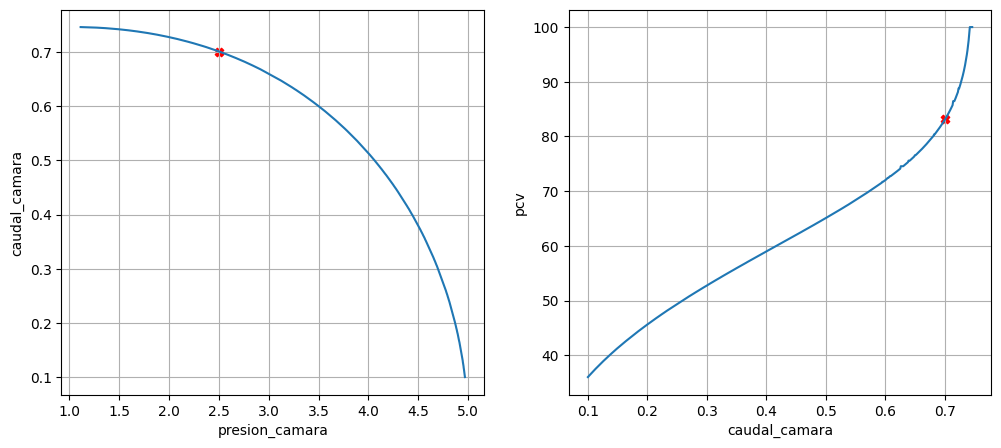

caudal_camara: 0.7002507151011679, pcv: 83.24616572676518


In [ ]:
feature = 'presion_camara'
value = 2.5

test(feature, value)

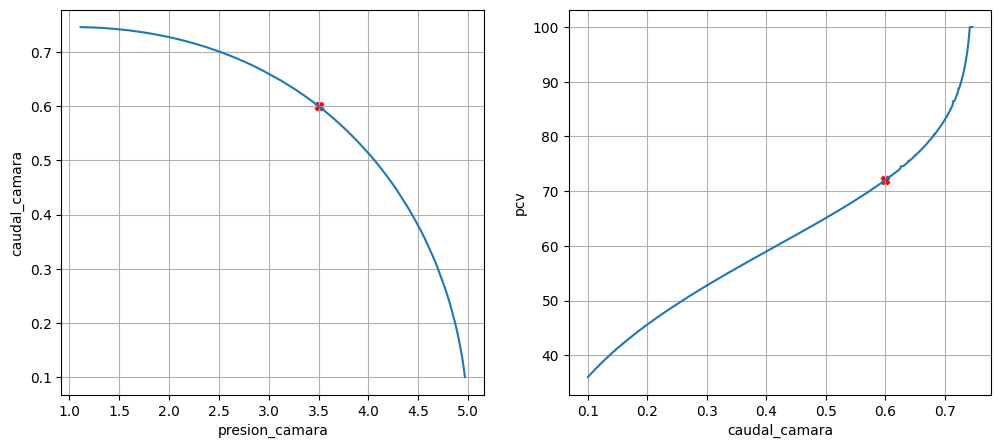

presion_camara: 3.5010202784717728, pcv: 72.06175153754995


In [ ]:
feature = 'caudal_camara'
value = 0.6

test(feature, value)

---
## v1
Contexto:
> * Feature: presión en cámara
> * Targets: caudal en cámara, PCV
> * regresión
> * 544 registros

Solución:
> ML y no ANN porque no es complejo y no hay suficientes datos. Modelo elegido: SVR, porque es bueno para curvas suaves.

Se utiliza "GridSearchCV" para automatizar la búsqueda de hiperparámetros.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### Dataset

In [ ]:
url = 'https://raw.githubusercontent.com/leito92/EEM/main/data/v1.csv'
df = pd.read_csv(url, sep=';')
display(df)

,#,presion_entrada,mfc,pcv,caudal_camara,presion_camara
0,Case 255,5,90,100,"0,746","1,112"
1,Case 256,5,90,100,"0,745","1,272"
2,Case 257,5,90,100,"0,744","1,363"
3,Case 258,5,90,100,"0,743","1,433"
4,Case 259,5,90,100,"0,742","1,493"
...,...,...,...,...,...,...
539,Case 897,5,90,"36,49","0,104","4,965"
540,Case 898,5,90,"36,37","0,103","4,966"
541,Case 899,5,90,"36,25","0,102","4,967"
542,Case 900,5,90,"36,13","0,101","4,967"


In [ ]:
# Convertir columnas con comas a formato numérico con puntos
columns_to_convert = ['pcv', 'caudal_camara', 'presion_camara']
for col in columns_to_convert:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

### Gráfico

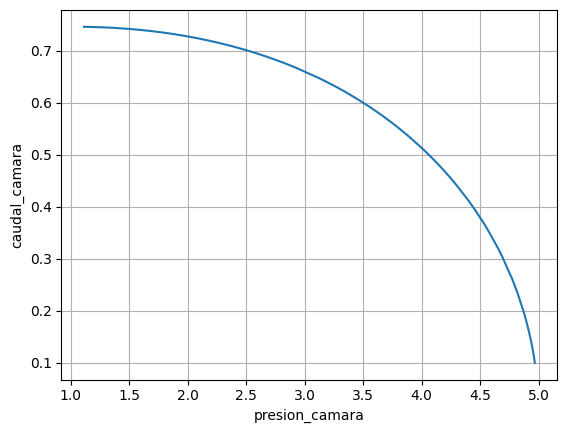

In [ ]:
plt.plot(df['presion_camara'], df['caudal_camara'])
plt.xlabel('presion_camara')
plt.ylabel('caudal_camara')
plt.grid(True)
plt.show()

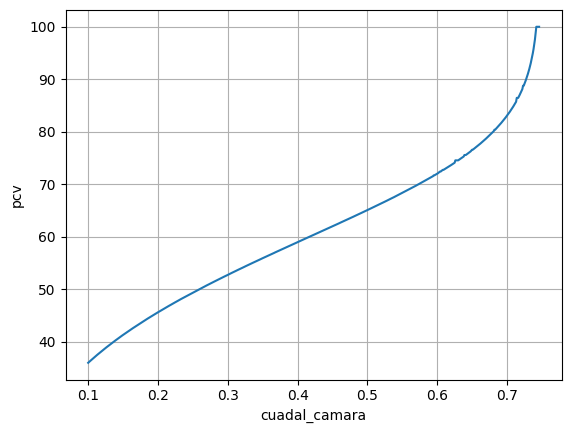

In [ ]:
plt.plot(df['caudal_camara'], df['pcv'])
plt.xlabel('cuadal_camara')
plt.ylabel('pcv')
plt.grid(True)
plt.show()

### Modelo ML

In [ ]:
def prepare_data(df):
  X = df[["presion_camara"]]
  y = df[["caudal_camara","pcv"]]

  X_rest, X_blind, y_rest, y_blind = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
  )

  X_train, X_test, y_train, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.20,
    random_state=42
  )

  total = len(X)
  print(f"PARTICIONES DE DATOS:")
  print(f"Total: {total} pts (100%)")
  print(f"Train: {len(X_train)} pts ({len(X_train)/total*100:.1f}%)")
  print(f"Test: {len(X_test)} pts ({len(X_test)/total*100:.1f}%)")
  print(f"Blind: {len(X_blind)} pts ({len(X_blind)/total*100:.1f}%)")

  return X_train, X_test, X_blind, y_train, y_test, y_blind

In [ ]:
candidates = {
    'SVR': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MultiOutputRegressor(SVR(kernel='rbf')))
        ]),
        'params': {
            'model__estimator__gamma': ['scale'],
            'model__estimator__C': [1, 10, 100, 1000],
            'model__estimator__epsilon': [0.1, 0.01, 0.001]
        }
    }
}

In [ ]:
def search_params(X_train, y_train, cv=5):
  results = {}

  print(f"\nBUSCANDO HIPERPARÁMETROS:")
  for name, candidate in candidates.items():
    gs = GridSearchCV(
        candidate['pipeline'],
        candidate['params'],
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    gs.fit(X_train, y_train)
    results[name] = {
        'best_score': gs.best_score_,
        'best_params': gs.best_params_,
        'best_estimator': gs.best_estimator_
    }
    print(f"Model: {name} → R² CV: {gs.best_score_:.4f} | Params: {gs.best_params_}")

  best_name = max(results, key=lambda k: results[k]['best_score'])
  print(f"\nMODELO SELECCIONADO: {best_name}")
  return results[best_name]['best_estimator']

In [ ]:
def pred(model, X, y):
  y_pred = model.predict(X)

  print(f"\nEVALUACIÓN:")
  for i, target in enumerate(['caudal_camara', 'pcv']):
    mae = mean_absolute_error(y.iloc[:, i], y_pred[:, i])
    mse = mean_squared_error(y.iloc[:, i], y_pred[:, i])
    r2  = r2_score(y.iloc[:, i], y_pred[:, i])
    print(f"{target} → MAE: {mae} | RMSE: {np.sqrt(mse)} | R²: {r2}")

  return y_pred

In [ ]:
X_train, X_test, X_blind, y_train, y_test, y_blind = prepare_data(df)
model = search_params(X_train, y_train)
y_test_pred = pred(model, X_test, y_test)

PARTICIONES DE DATOS:
Total: 544 pts (100%)
Train: 391 pts (71.9%)
Test: 98 pts (18.0%)
Blind: 55 pts (10.1%)

BUSCANDO HIPERPARÁMETROS:
Model: SVR → R² CV: -0.1614 | Params: {'model__estimator__C': 1000, 'model__estimator__epsilon': 0.001, 'model__estimator__gamma': 'scale'}

MODELO SELECCIONADO: SVR

EVALUACIÓN:
caudal_camara → MAE: 0.0008436152234120504 | RMSE: 0.0012660059245799644 | R²: 0.9999535193049954
pcv → MAE: 0.16689264732452083 | RMSE: 0.43251407310844925 | R²: 0.999090860856862


### Test


EVALUACIÓN:
caudal_camara → MAE: 0.0008069601270957052 | RMSE: 0.0009571547921426127 | R²: 0.9999787026630862
pcv → MAE: 0.19028976964701422 | RMSE: 0.3764264112085529 | R²: 0.9994620400646438


,caudal_camara_real,caudal_camara_pred,pcv_real,pcv_pred
0,0.196,0.1960,45.31,44.9474
1,0.427,0.4282,60.61,60.5672
2,0.311,0.3103,53.47,53.6001
3,0.113,0.1138,37.53,38.7010
4,0.101,0.1041,36.13,37.9963
5,0.651,0.6520,76.59,76.5654
6,0.570,0.5710,69.77,69.7739
7,0.652,0.6532,76.70,76.6763
8,0.641,0.6411,75.58,75.5628
9,0.281,0.2817,51.50,51.6075


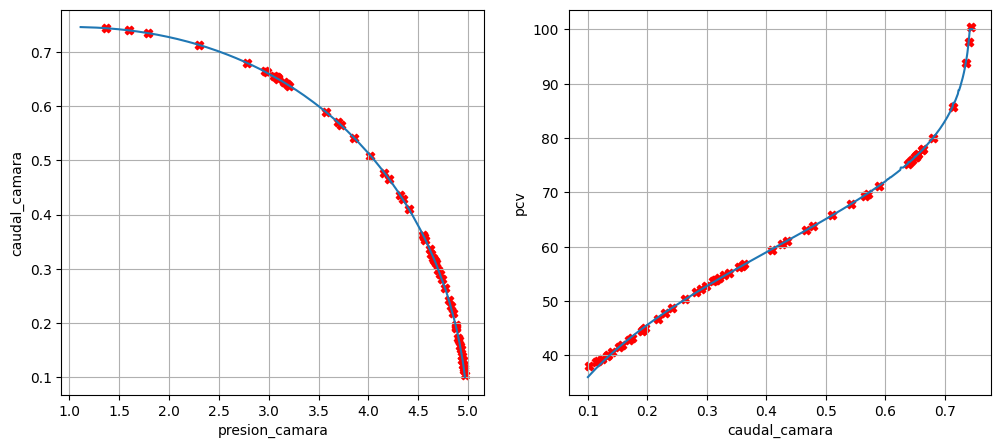

In [ ]:
y_blind_pred = pred(model, X_blind, y_blind)

resultado = pd.DataFrame({
    'caudal_camara_real': y_blind['caudal_camara'].values,
    'caudal_camara_pred': y_blind_pred[:, 0].round(4),
    'pcv_real':           y_blind['pcv'].values,
    'pcv_pred':           y_blind_pred[:, 1].round(4)
})
display(resultado)

fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(df["presion_camara"], df["caudal_camara"])
ax[0].scatter(
    X_blind, y_blind_pred[:, 0],
    marker="X", color="red"
)
ax[0].set_xlabel('presion_camara')
ax[0].set_ylabel('caudal_camara')
ax[0].grid(True)

ax[1].plot(df["caudal_camara"], df["pcv"])
ax[1].scatter(
    y_blind['caudal_camara'], y_blind_pred[:, 1],
    marker="X", color="red"
)
ax[1].set_xlabel('caudal_camara')
ax[1].set_ylabel('pcv')
ax[1].grid(True)

plt.show()

### Test 2

In [ ]:
presion_camara = 2.5
X = pd.DataFrame({'presion_camara': [presion_camara]})
output_pred = model.predict(X)
print(f"caudal_camara: {output_pred[0][0]}, pcv: {output_pred[0][1]}")

caudal_camara: 0.7002507151011679, pcv: 83.24616572676518


In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(df["presion_camara"], df["caudal_camara"])
ax[0].scatter(
    presion_camera, output_pred[0][0],
    marker="X", color="red"
)
ax[0].set_xlabel('presion_camara')
ax[0].set_ylabel('caudal_camara')
ax[0].grid(True)

ax[1].plot(df["caudal_camara"], df["pcv"])
ax[1].scatter(
    output_pred[0][0], output_pred[0][1],
    marker="X", color="red"
)
ax[1].set_xlabel('caudal_camara')
ax[1].set_ylabel('pcv')
ax[1].grid(True)
plt.show()

---
# 2025

Contexto:
> * Features: tipo de gas, caudal en cámara, presión en cámara
> * Targets: presión de entrada, MFC, PCV
> * Generar N configuraciones posibles dadas las condiciones de entrada

Se utiliza "Optuna" (framework) para automatizar la búsqueda de hiperparámetros.

## Datasets

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/gdrive')

gdrive_path = '/content/gdrive/MyDrive/EEM+AI'

df_co2 = pd.read_excel(f'{gdrive_path}/dataset_co2.xlsx')
df_ch4 = pd.read_excel(f'{gdrive_path}/dataset_ch4.xlsx')

df = pd.concat([df_co2, df_ch4], ignore_index=True)
display(df)

## Gráfico

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.scatter(df_co2['presion_camara'], df_co2['caudal_camara'])
ax.set_xlabel('Presión cámara [kg/cm2_g]', fontsize=11)
ax.set_ylabel('Caudal cámara [m3/d_(gas)]', fontsize=11)
ax.set_title('Gas CO2' , fontsize=12, fontweight='bold')
ax.grid(True, linewidth=0.5, alpha=0.3, color='gray')

ax = axes[1]
ax.scatter(df_ch4['presion_camara'], df_ch4['caudal_camara'])
ax.set_xlabel('Presión cámara [kg/cm2_g]', fontsize=11)
ax.set_ylabel('Caudal cámara [m3/d_(gas)]', fontsize=11)
ax.set_title('Gas CH4' , fontsize=12, fontweight='bold')
ax.grid(True, linewidth=0.5, alpha=0.3, color='gray')

plt.tight_layout()
plt.show()

## Modelo NN

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import copy
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
!pip install optuna
import optuna
import time

In [ ]:
def prepare_data(df):
  le = LabelEncoder()
  df['tipo_gas_encoded'] = le.fit_transform(df['gas'])

  X = df[['tipo_gas_encoded', 'caudal_camara', 'presion_camara']].values
  y = df[['presion_entrada', 'mfc', 'pcv']].values

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, shuffle=True
  )

  scaler_X = StandardScaler()
  scaler_y = StandardScaler()

  X_train = scaler_X.fit_transform(X_train)
  X_test = scaler_X.transform(X_test)
  y_train = scaler_y.fit_transform(y_train)
  y_test = scaler_y.transform(y_test)

  return X_train, X_test, y_train, y_test, (scaler_X, scaler_y), le

In [ ]:
class GasDataset(Dataset):
  """ Dataset optimizado para PyTorch """

  def __init__(self, X, y):
      self.X = torch.FloatTensor(X)
      self.y = torch.FloatTensor(y)

  def __len__(self):
      return len(self.X)

  def __getitem__(self, idx):
      return self.X[idx], self.y[idx]

In [ ]:
class MixtureDensityNetwork(nn.Module):
  """ El modelo Mixture Density Network (MDN) es una red neuronal que en lugar
  de predecir un solo valor, predice una distribución de probabilidad
  representada como una mezcla de gaussianas. """

  def __init__(self, input_dim, output_dim, n_gaussians, hidden_dims):
    super().__init__()

    self.input_dim = input_dim
    self.output_dim = output_dim
    self.n_gaussians = n_gaussians # N solcuiones alternativas

    # Red neuronal compartida por los outputs
    layers = []
    prev_dim = input_dim
    for hidden_dim in hidden_dims:
      layers.extend([
        nn.Linear(prev_dim, hidden_dim), # Capa densa
        nn.ReLU(), # Activación
        nn.BatchNorm1d(hidden_dim), # Normalización
        nn.Dropout(0.2) # Regulación
      ])
      prev_dim = hidden_dim

    self.shared_net = nn.Sequential(*layers)

    # Capas de salida predice 3 parámetros para cada gaussiana
    # Media
    self.mu_layer = nn.Linear(prev_dim, n_gaussians * output_dim)
    # Desviación
    self.sigma_layer = nn.Linear(prev_dim, n_gaussians * output_dim)
    # Peso/Probabilidad
    self.pi_layer = nn.Linear(prev_dim, n_gaussians)


  def forward(self, x): # Procesamiento
    h = self.shared_net(x)

    mu = self.mu_layer(h).view(-1, self.n_gaussians, self.output_dim)
    sigma = torch.exp(self.sigma_layer(h)).view(-1, self.n_gaussians, self.output_dim)
    pi = torch.softmax(self.pi_layer(h), dim=1)

    return mu, sigma, pi

In [ ]:
def mdn_loss(mu, sigma, pi, target):
  """ Maximiza la probabilidad de los datos """

  target = target.unsqueeze(1).expand_as(mu)

  normal = torch.distributions.Normal(mu, sigma)
  log_prob = normal.log_prob(target).sum(dim=2)
  log_pi = torch.log(pi + 1e-8)
  weighted_log_prob = log_pi + log_prob

  loss = -torch.logsumexp(weighted_log_prob, dim=1)

  return loss.mean()

In [ ]:
def train_mdn(model, train_loader, val_loader, epochs, lr, device,
              early_stopping_patience, trial):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    print(f"\n{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12}")
    print("-" * 35)

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            mu, sigma, pi = model(X_batch)
            loss = mdn_loss(mu, sigma, pi, y_batch)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                mu, sigma, pi = model(X_batch)
                loss = mdn_loss(mu, sigma, pi, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        # Reportar a Optuna (para pruning)
        trial.report(val_loss, epoch)

        # Si Optuna decide que este trial es malo, lo detiene
        if trial.should_prune():
            raise optuna.TrialPruned()

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"{epoch+1:<8} {train_loss:<12.4f} {val_loss:<12.4f}")

        # Early stopping check
        if early_stopping_patience and epochs_without_improvement >= early_stopping_patience:
          print("-" * 35)
          print(f"Early stopping en epoch {epoch+1}")
          print(f"Val loss no mejoró por {early_stopping_patience} epochs")
          print(f"Mejor val loss: {best_val_loss:.4f}")
          break

    model.load_state_dict(best_model_state)

    return train_losses, val_losses

In [ ]:
def plot_training_curves(train_losses, val_losses):
  plt.figure(figsize=(5, 3))
  plt.plot(train_losses, label='Train Loss', linewidth=2)
  plt.plot(val_losses, label='Val Loss', linewidth=2)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.legend(fontsize=11)
  plt.title('Evolución del Entrenamiento', fontsize=12, fontweight='bold')
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

In [ ]:
def get_arch(type):
  arch_map = {
        'tiny': [16, 8],
        'small': [32, 16],
        'medium': [64, 32],
        'large': [128, 64, 32]
    }
  return arch_map[type]

In [ ]:
def objective(train_dataset, test_dataset, device, trial, best_model):
  n_gaussians = trial.suggest_int('n_gaussians', 3, 10)
  epochs = trial.suggest_int('epochs', 100, 500, step=50)
  lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
  early_stopping = trial.suggest_int('early_stopping_patience', 20, 30, step=5)
  arch_type = trial.suggest_categorical('architecture', ['tiny', 'small', 'medium', 'large'])
  hidden_dims = get_arch(arch_type)
  batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

  model = MixtureDensityNetwork(
      input_dim=3,
      output_dim=3,
      n_gaussians=n_gaussians,
      hidden_dims=hidden_dims
  )

  train_losses, val_losses = train_mdn(
      model, train_loader, test_loader,
      epochs=epochs,
      lr=lr,
      device=device,
      early_stopping_patience=early_stopping,
      trial=trial
  )

  final_val_loss = val_losses[-1]
  if 'best_val_loss' not in best_model or final_val_loss < best_model['best_val_loss']:
      best_model['model'] = model
      best_model['train_losses'] = train_losses
      best_model['val_losses'] = val_losses

  return final_val_loss

In [ ]:
def get_diverse_predictions(model, X, n_solutions, device):
  model.eval()
  with torch.no_grad():
    X = torch.FloatTensor(X).to(device)
    mu, sigma, pi = model(X)

    batch_size = X.shape[0]
    all_solutions = []
    component_probs = [] # Lista para almacenar las probabilidades de cada solución

    # Usar las componentes con mayor peso/prob
    top_k_pi, top_k_idx = torch.topk(pi, k=min(n_solutions, pi.shape[1]), dim=1)

    for i in range(min(n_solutions, pi.shape[1])):
      component_idx = top_k_idx[:, i]
      selected_mu = mu[torch.arange(batch_size), component_idx]
      selected_prob = top_k_pi[0, i].item()  # Probabilidad (escalar)
      all_solutions.append(selected_mu.cpu().numpy())
      component_probs.append(selected_prob) # Almacenar la probabilidad escalar

    solutions = np.stack(all_solutions, axis=1)

  return solutions, component_probs

In [ ]:
def create_model(df, device, n_trials, optuna_timeout=None):
  best_model = {}

  # Step 1
  X_train, X_test, y_train, y_test, (scaler_X, scaler_y), le = prepare_data(df)

  train_dataset = GasDataset(X_train, y_train)
  test_dataset = GasDataset(X_test, y_test)

  # Step 2
  study = optuna.create_study(
      direction='minimize',
      pruner=optuna.pruners.MedianPruner(
          n_startup_trials=5,
          n_warmup_steps=10
      )
  )

  start_time = time.time()
  study.optimize(
      lambda trial: objective(train_dataset, test_dataset, device, trial, best_model),
      n_trials=n_trials, # Número de combinaciones a probar
      timeout=optuna_timeout,
      show_progress_bar=True
  )
  elapsed = time.time() - start_time

  print("\nResultados:")
  print("-" * 35)
  print(f"Tiempo total: {elapsed/60:.1f} minutos")
  print(f"Mejor val_loss: {study.best_value:.4f}")
  print(f"Mejores hiperparámetros:")
  for key, value in study.best_params.items():
      print(f"  {key}: {value}")

  # Step 3
  best_params = study.best_params
  hidden_dims = get_arch(best_params.get('architecture'))
  epochs = best_params.get('epochs')
  lr = best_params.get('lr')
  n_gaussians = best_params.get('n_gaussians')
  early_stopping_patience = best_params.get('early_stopping_patience')
  batch_size = best_params.get('batch_size')

  model = best_model['model']
  train_losses = best_model['train_losses']
  val_losses = best_model['val_losses']

  # Step 4
  plot_training_curves(train_losses, val_losses)

  # Step 5
  torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'label_encoder': le,
    'config': {
      'input_dim': 3,
      'output_dim': 3,
      'n_gaussians': n_gaussians,
      'hidden_dims': hidden_dims,
      'lr': lr,
      'epochs': epochs,
      'batch_size': batch_size,
      'early_stopping_patience': early_stopping_patience
    }
  }, f'{gdrive_path}/mdn_model.pth')

  return model, scaler_X, scaler_y, le

In [ ]:
def load_model(model_path, device):
  # Cargar checkpoint
  checkpoint = torch.load(model_path, map_location=device, weights_only=False)

  # Recrear modelo con la configuración guardada
  config = checkpoint['config']
  model = MixtureDensityNetwork(
      input_dim=config['input_dim'],
      output_dim=config['output_dim'],
      n_gaussians=config['n_gaussians'],
      hidden_dims=config['hidden_dims']
  )

  # Cargar pesos entrenados
  model.load_state_dict(checkpoint['model_state_dict'])
  model = model.to(device)
  model.eval()  # Modo evaluación

  # Cargar scalers y encoder
  scaler_X = checkpoint['scaler_X']
  scaler_y = checkpoint['scaler_y']
  le = checkpoint['label_encoder']

  print("Modelo cargado:")
  print(f"Gaussianas: {config['n_gaussians']}")
  print(f"Arquitectura: {config['hidden_dims']}")
  print(f"LR: {config['lr']:.6f}")
  print(f"Epochs: {config['epochs']}")
  print(f"Batch size: {config['batch_size']}")
  print(f"Early stopping: {config['early_stopping_patience']}")

  return model, scaler_X, scaler_y, le

In [ ]:
def predict_solutions(model, tipo_gas, caudal, presion, scaler_X, scaler_y, le, n_solutions, device):
  tipo_gas_encoded = le.transform([tipo_gas])[0]
  X = np.array([[tipo_gas_encoded, caudal, presion]])
  X_scaled = scaler_X.transform(X)

  # Se usa el n_solutions pero limitado por las gaussianas del modelo
  n_solutions_to_extract = min(n_solutions, model.n_gaussians)
  predictions, probabilities = get_diverse_predictions(model, X_scaled, n_solutions_to_extract, device)
  predictions_denorm = scaler_y.inverse_transform(predictions.reshape(-1, 3)).reshape(predictions.shape)

  results = []
  for i in range(predictions_denorm.shape[1]):
      results.append({
          'solucion': i+1,
          'presion_entrada': float(predictions_denorm[0, i, 0]),
          'MFC': float(predictions_denorm[0, i, 1]),
          'PCV': float(predictions_denorm[0, i, 2]),
          '%': probabilities[i] * 100
      })

  return pd.DataFrame(results)

## Test

In [ ]:
device='cuda'
n_trials=30
optuna_timeout=3600
gas='co2'
caudal=0.5
presion=7
n_solutions=5

#model, scaler_X, scaler_y, le = create_model(df, device=device, n_trials=n_trials, optuna_timeout=optuna_timeout)
model, scaler_X, scaler_y, le = load_model(f'{gdrive_path}/mdn_model.pth', device)

solutions = predict_solutions(model, gas, caudal, presion, scaler_X, scaler_y, le, n_solutions, device)
display(solutions)

In [ ]:
print(type(model))
print(model)

## Modelo Edge

In [ ]:
import os

def get_model_size(model):
  torch.save(model.state_dict(), 'temp_model.pth')
  size = os.path.getsize('temp_model.pth') / 1e6  # MB
  os.remove('temp_model.pth')

  return size

In [ ]:
def create_edge_model(model_path):
  # Cargar checkpoint
  checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
  print(checkpoint['config'])
  config = checkpoint['config']

  # Recrear modelo
  model = MixtureDensityNetwork(
      input_dim=config['input_dim'],
      output_dim=config['output_dim'],
      n_gaussians=config['n_gaussians'],
      hidden_dims=config['hidden_dims']
  )

  model.load_state_dict(checkpoint['model_state_dict'])
  model = model.to('cpu')
  model.eval()

  # Cuantización
  quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear},
    dtype=torch.qint8
  )

  # Comparar tamaños
  original_size = get_model_size(model)
  print(f"Tamaño original: {original_size:.2f} MB")
  quantized_size = get_model_size(quantized_model)
  print(f"Tamaño cuantizado: {quantized_size:.2f} MB")
  print(f"Reducción: {(1 - quantized_size/original_size)*100:.1f}%")

  torch.save({
    'model': quantized_model,
    'scaler_X': checkpoint['scaler_X'],
    'scaler_y': checkpoint['scaler_y'],
    'label_encoder': checkpoint['label_encoder'],
    'config': config
  }, f'{gdrive_path}/mdn_edge_model.pth')

  return quantized_model

In [ ]:
def load_edge_model(edge_model_path):
  checkpoint = torch.load(edge_model_path, map_location='cpu', weights_only=False)
  model = checkpoint['model']
  model.eval()

  scaler_X = checkpoint['scaler_X']
  scaler_y = checkpoint['scaler_y']
  label_encoder = checkpoint['label_encoder']
  config = checkpoint['config']

  print("Modelo edge cargado correctamente")
  print(f"Gaussianas: {config['n_gaussians']}")
  print(f"Arquitectura: {config['hidden_dims']}")

  return model, scaler_X, scaler_y, label_encoder

## Test 2

In [ ]:
gas='co2'
caudal=0.5
presion=7
n_solutions=3

model_edge = create_edge_model(f'{gdrive_path}/mdn_model.pth')
#model_edge, scaler_X, scaler_y, le = load_edge_model(f'{gdrive_path}/mdn_edge_model.pth')

solutions = predict_solutions(model_edge, gas, caudal, presion, scaler_X, scaler_y, le, n_solutions, 'cpu')
display(solutions)

In [ ]:
def inference(model, device):
  # Mide velocidad en generar 1 predicción

  model.eval()

  X_train, X_test, y_train, y_test, (scaler_X, scaler_y), le = prepare_data(df)

  # Warm-up
  with torch.no_grad():
      X_sample = torch.FloatTensor(X_test[:1]).to(device)
      for _ in range(10):
          _ = model(X_sample)

  # Test
  times = []
  with torch.no_grad():
      X_sample = torch.FloatTensor(X_test[:1]).to(device)
      for _ in range(100):
          start = time.time()
          _ = model(X_sample)
          times.append((time.time() - start) * 1000)  # ms

  avg_time = np.mean(times)
  std_time = np.std(times)

  print(f"Tiempo promedio: {avg_time:.2f} ± {std_time:.2f} ms")

In [ ]:
inference(model, 'cuda')
inference(model_edge, 'cpu')